<a href="https://colab.research.google.com/github/ErenB02/compneuro/blob/main/lectures/W2D2_Tutorial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 3: Filters, Convolution & the Convolution Theorem

**Week 2, Day 2: Time series and signal processing**

**By Neuromatch Academy (community contribution)**

**Content Creators:** Noga Mudrik, Adam Manoogian, Ria Cheruvu

**Content Reviewers:** Sricharan Sunder, Gal Vishne, Richard Gao

**Production editors:** Konstantine Tsafatinos

---

# Tutorial Objectives

*Estimated timing of tutorial: 45 minutes*

Filters let us isolate the parts of a neural signal we care about. In this tutorial we build the signal-processing toolkit you will use throughout the course.

We start from the idea that a **linear time-invariant (LTI) system** is fully described by its impulse response, learn that **convolution** is the operation that maps inputs to outputs, and discover the **convolution theorem** that makes filtering intuitive in the frequency domain.

We then turn to **filters** -- LTI systems whose frequency response we choose deliberately -- and explore practical filter design, the tradeoffs involved, and the artifacts that arise when filters are applied carelessly to neural data.

By the end of this tutorial you will be able to:

- Define LTI systems and explain why the impulse response fully characterises one
- Implement and verify discrete convolution
- State and verify the convolution theorem numerically
- Recognise canonical Fourier transform pairs and their implications
- Design and apply low-pass, high-pass, band-pass, and notch filters
- Identify common filtering artifacts (ringing, phase distortion, spike-induced oscillations)
- Separate local field potential (LFP) and spikes from a real Neuropixels recording using filters

---

In [ ]:
# @title Tutorial slides
# @markdown These are the slides for all videos in this tutorial.
from IPython.display import IFrame
link_id = "583n4"
print(f"If you want to download the slides: https://osf.io/download/{link_id}/")
IFrame(src=f"https://mfr.ca-1.osf.io/render?url=https://osf.io/{link_id}/?direct%26mode=render%26action=download%26mode=render", width=854, height=480)

# Setup

In [1]:
# @title Install and import feedback gadget
!pip3 install vibecheck datatops --quiet
from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()
feedback_prefix = "W2D2_T3"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.1 MB/s eta 0:00:00


In [2]:
# @title Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from ipywidgets import interact
import warnings
warnings.filterwarnings('ignore')

In [3]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [4]:
# @title Helper Functions

def make_impulse(n, position=0):
    """Create a unit impulse at the given position."""
    x = np.zeros(n)
    x[position] = 1.0
    return x


def leaky_integrator_response(t, tau):
    """Impulse response of a leaky integrator: h(t) = (1/tau) * exp(-t/tau) for t >= 0."""
    h = np.zeros_like(t)
    h[t >= 0] = (1.0 / tau) * np.exp(-t[t >= 0] / tau)
    return h


def plot_time_and_freq(t, x, fs, title="Signal", color='C0'):
    """Side-by-side time domain and frequency domain plot."""
    freqs = np.fft.rfftfreq(len(x), 1.0 / fs)
    X = np.abs(np.fft.rfft(x)) / len(x)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t * 1000, x, color=color, lw=1.2)
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(title + " — Time Domain")
    ax2.plot(freqs, X, color=color)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("|X(f)|")
    ax2.set_title(title + " — Frequency Domain")
    plt.tight_layout()
    plt.show()


# --------------- Plotting functions ---------------

def plot_filter_responses(b, a, fs, filter_name='Filter'):
    """Plot amplitude response, phase response, and impulse response."""
    w, h = signal.freqz(b, a, worN=8000, fs=fs)
    imp = np.zeros(200); imp[0] = 1.0
    imp_response = signal.lfilter(b, a, imp)
    t_imp = np.arange(200) / fs

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(w, 20 * np.log10(np.abs(h) + 1e-10))
    axes[0].axhline(-3, color='gray', linestyle='--', alpha=0.6, label='-3 dB')
    axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Amplitude (dB)')
    axes[0].set_title('Amplitude Response'); axes[0].legend()

    axes[1].plot(w, np.unwrap(np.angle(h)))
    axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Phase (radians)')
    axes[1].set_title('Phase Response')

    axes[2].plot(t_imp * 1000, imp_response)
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[2].set_xlabel('Time (ms)'); axes[2].set_ylabel('Amplitude')
    axes[2].set_title('Impulse Response')

    plt.suptitle(filter_name, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def compare_filtered_signals(t, signals_dict, title='Filter Comparison', xlim=None):
    """Overlay multiple filtered versions of a signal."""
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, (x, color) in signals_dict.items():
        ax.plot(t * 1000, x, label=label, color=color, lw=1.2, alpha=0.85)
    if xlim:
        ax.set_xlim(xlim)
    ax.set_xlabel('Time (ms)'); ax.set_ylabel('Amplitude (a.u.)')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()


def plot_signal_and_spectrum(t, x, fs, title='Signal', color='C0'):
    """Side-by-side time domain and frequency domain."""
    freqs = np.fft.rfftfreq(len(x), 1 / fs)
    X = np.abs(np.fft.rfft(x)) / len(x)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t * 1000, x, color=color, lw=0.8)
    ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Amplitude (a.u.)')
    ax1.set_title(title + ' -- Time Domain')
    ax2.plot(freqs, X, color=color)
    ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|X(f)|')
    ax2.set_title(title + ' -- Frequency Domain')
    plt.tight_layout(); plt.show()


# --------------- Helper functions ---------------

def make_lfp_signal(fs=1000.0, duration=2.0, seed=42):
    """Simulated LFP: theta (6 Hz) + gamma (60 Hz) + pink noise + two spike transients."""
    rng = np.random.default_rng(seed)
    t = np.arange(0, duration, 1 / fs)
    theta = 1.5 * np.sin(2 * np.pi * 6 * t)
    gamma = 0.4 * np.sin(2 * np.pi * 60 * t)
    white = rng.standard_normal(len(t))
    freqs_n = np.fft.rfftfreq(len(t), 1 / fs)
    freqs_n[0] = 1
    pink = np.real(np.fft.irfft(
        np.fft.rfft(white) / np.sqrt(freqs_n), n=len(t))) * 0.3
    spikes = np.zeros(len(t))
    for st in [0.5, 1.3]:
        idx = int(st * fs)
        spikes[idx] = 5.0
        if idx + 1 < len(t):
            spikes[idx + 1] = -3.0
    return t, theta + gamma + pink + spikes


def apply_filter(x, b, a, causal=True):
    """Apply a digital filter, causal (lfilter) or zero-phase (filtfilt)."""
    return signal.lfilter(b, a, x) if causal else signal.filtfilt(b, a, x)


def make_impulse_at_quarter(n_samples=500):
    """Unit impulse at the 1/4 point (for filter artifact demos)."""
    imp = np.zeros(n_samples)
    imp[n_samples // 4] = 1.0
    return imp

---

# Section 1: Introduction

*Estimated timing to here from start of tutorial: 0 min*

In [ ]:
# @title Video 1: Introduction to filtering

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'd52akMqjNLg'), ('Bilibili', 'BV1YZTz6HEBV')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_1_Intro")

---

# Section 2: Why do we need filters?

*Estimated timing to here from start of tutorial: 1 min*

## What is a system?

In Tutorials 1 and 2 we learned how to sample signals and decompose them into frequency components using the Fourier Transform. Now we ask a different question: what happens when a signal passes through a "system"?

A **system** is anything that takes an input signal and produces an output signal. In neuroscience, systems are everywhere:

- A recording electrode transforms neural voltage into a digital signal
- A neuron transforms synaptic input into a membrane potential response
- A sensor transforms a physical stimulus into a neural signal

## Filters: engineered systems that isolate signals

Raw neuroscience data is often a messy mix of:

1. Our signal of interest, including the specific rhythm or event you are studying (e.g., Theta oscillations).
2. Biological noise, including other brain activity you aren't currently focusing on (e.g., muscle artifacts).
3. Environmental noise, including electrical interference from the building (e.g., 50/60 Hz mains hum - 60 Hz in North America and parts of Asia, 50 Hz in Europe and most of the rest of the world).

Filtering is the process of selective listening, to make sense from the noise.

Imagine you want to isolate the Theta band (4-8 Hz) in an LFP recording to study hippocampal navigation. We can think of a filter as a "frequency mask" where we set:

$$H(f) = 1 \quad \text{for} \quad f \in [4, 8] \text{ Hz}$$
$$H(f) = 0 \quad \text{everywhere else}$$

By multiplying our data's spectrum by this mask, we "keep" the theta and "mute" everything else.

---

## Operating in time vs. frequency domain

**You've seen $H(f)$ before in Tutorials 1 and 2. There, it appeared as the magnitude and phase spectrum of a signal.** Here, a filter is a *"linear time-invariant (LTI)" system* with a deliberately chosen frequency response $H(f)$, which changes the amplitude and phase of the input signal in specific ways.

We will cover the **convolution theorem** in the later sections, which shows that the *same operation* can be performed in time or frequency domain:

$$y(t) = x(t) * h(t)$$

$$Y(f) = \mathcal{F}\{y(t)\} = X(f) \cdot H(f)$$

As you will later see, the cool thing is that filtering can be implemented as **simply a multiplication in the frequency domain**; we choose $H(f)$ to keep what we want and suppress what we don't.


## Types of filters
Filters are a common foundation in data processing, with some particularly common examples highlighted in the table below:

| Filter Type | Passes | Suppresses | Example goals in neuroscience |
|---|---|---|---|
| **Low-pass (LP)** | Low frequencies | High frequencies | Smoothing, isolating slow LFP fluctuations |
| **High-pass (HP)** | High frequencies | Low frequencies | Removing drift, isolating spikes from raw recordings |
| **Band-pass (BP)** | A narrow frequency band | Everything outside | Isolating theta, alpha, gamma oscillations |
| **Notch / Band-stop** | Everything else | A narrow frequency band | Removing 50/60 Hz line noise |

Later in the tutorial, we will use a combination of filters to separate LFP and spikes in the IBL Neuropixels dataset.

Here, we first show you what some of these filters look like in the time and frequency domains, and then dive into the math behind them:
- **Left — amplitude response:** how much each frequency is attenuated, exactly like the magnitude spectrum you saw in the previous tutorial
- **Middle — phase response:** which shows how the filter shifts the phase of different frequencies
- **Right — impulse response:** the output of a filter in time domain, in response to a single "impulse" input.

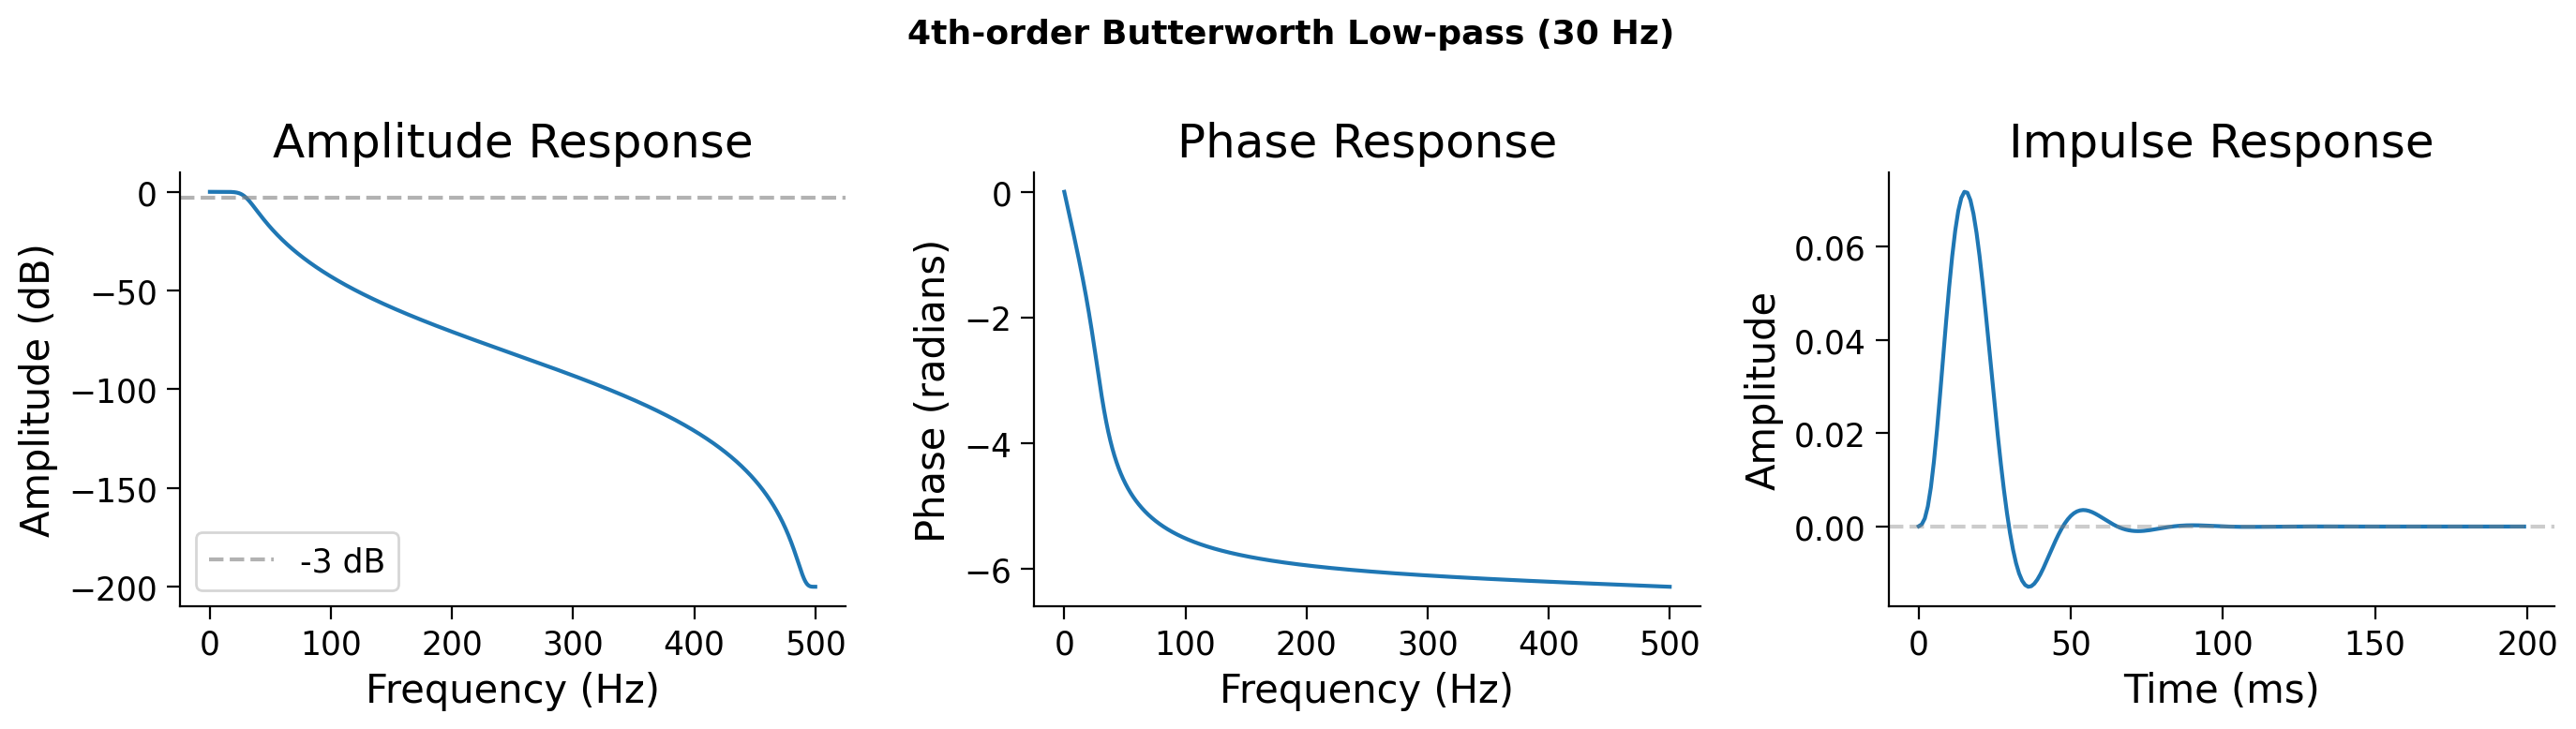

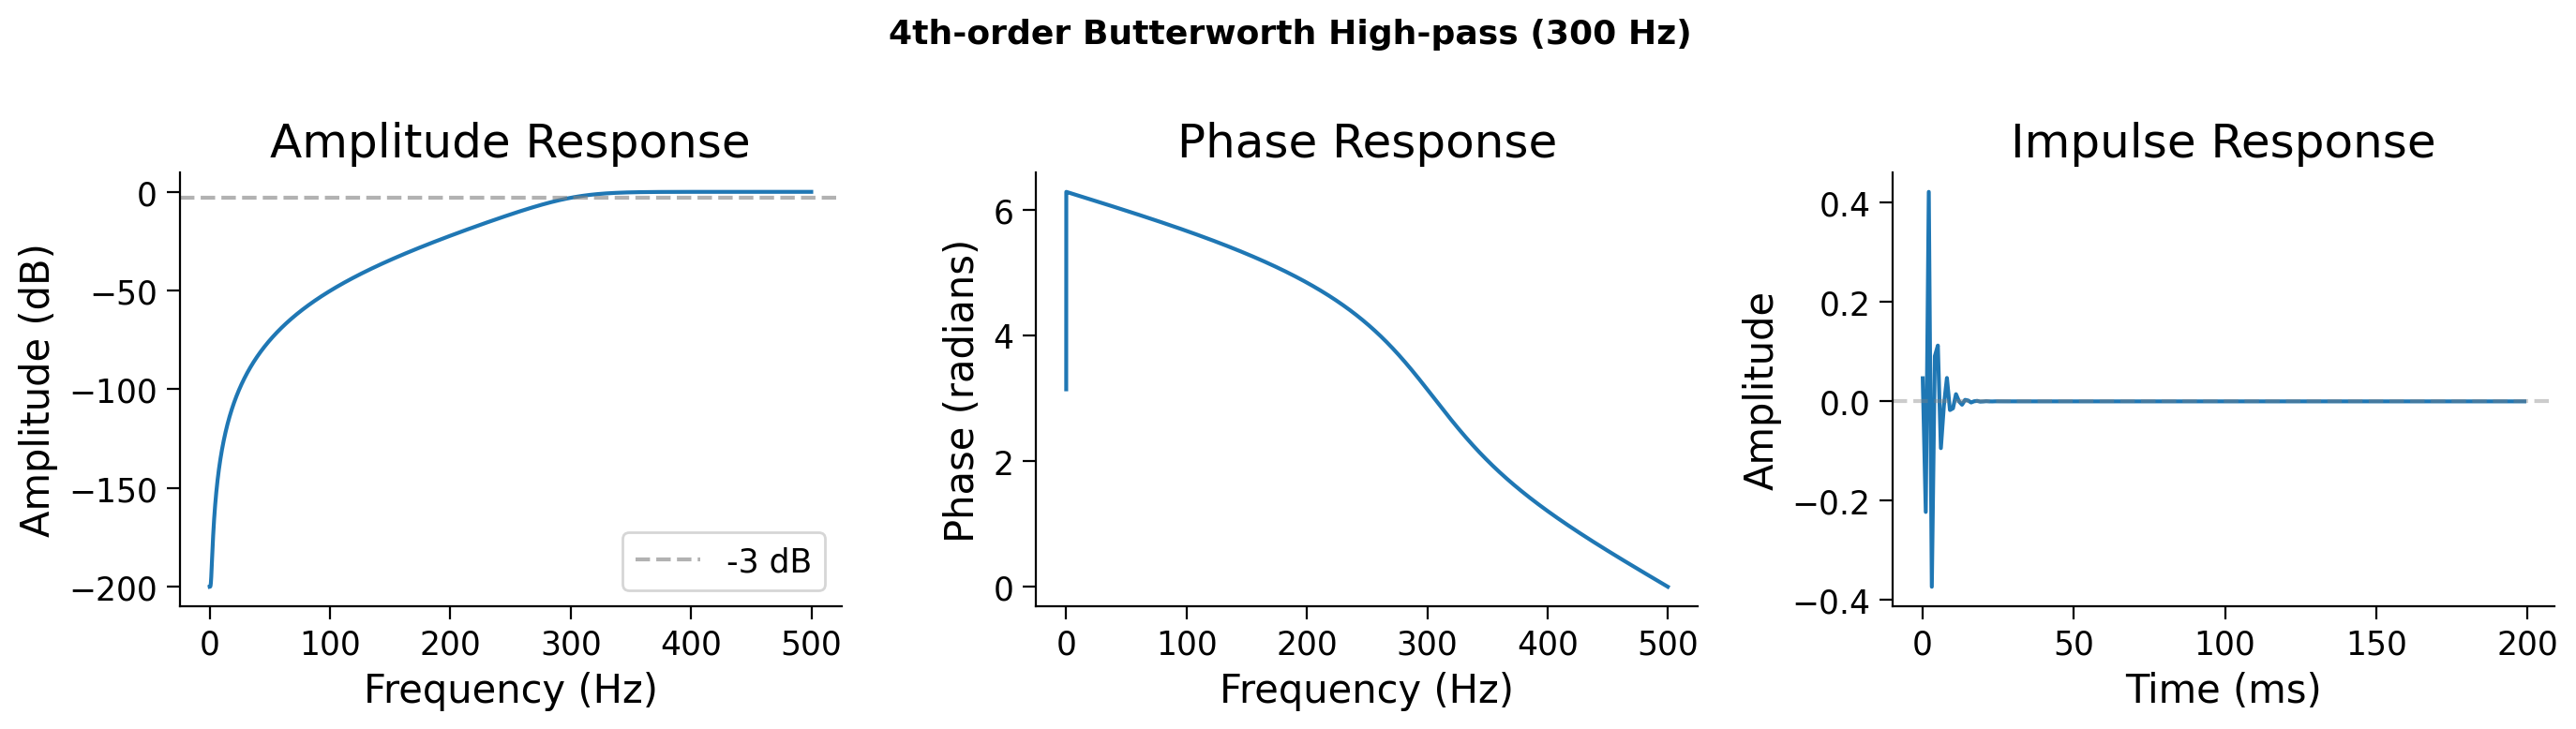

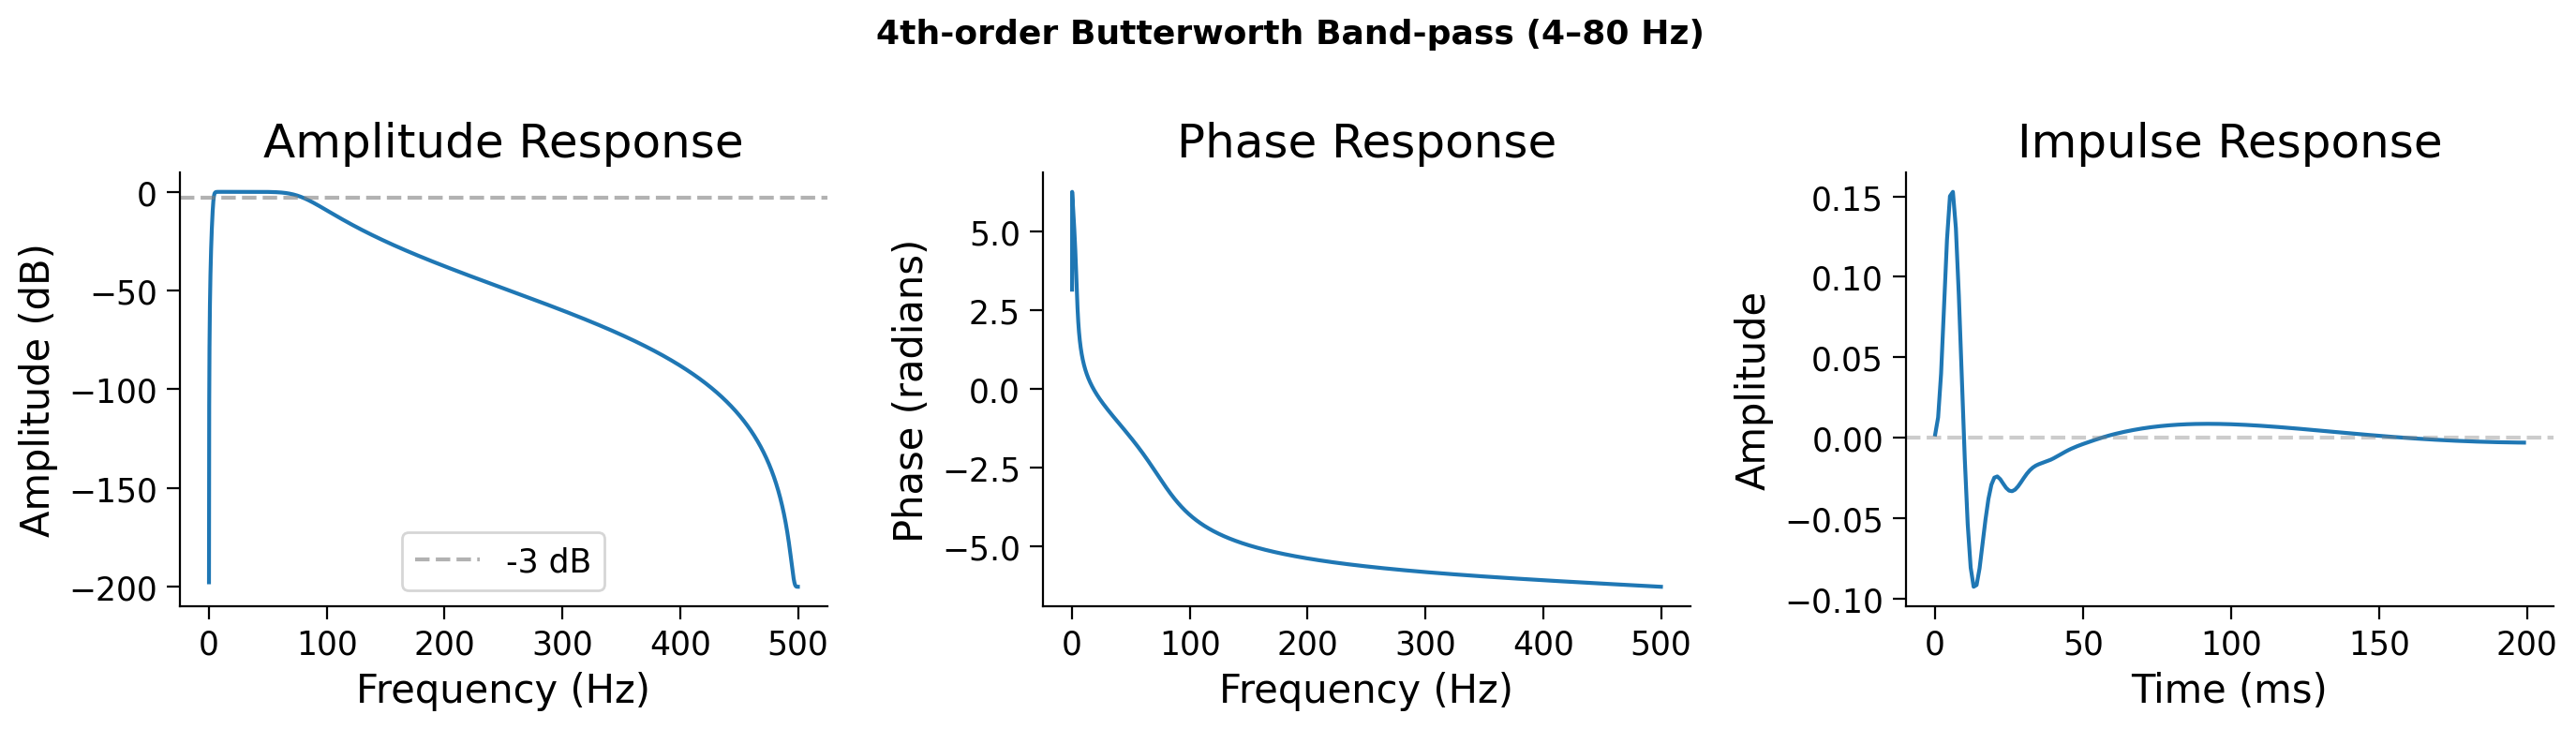

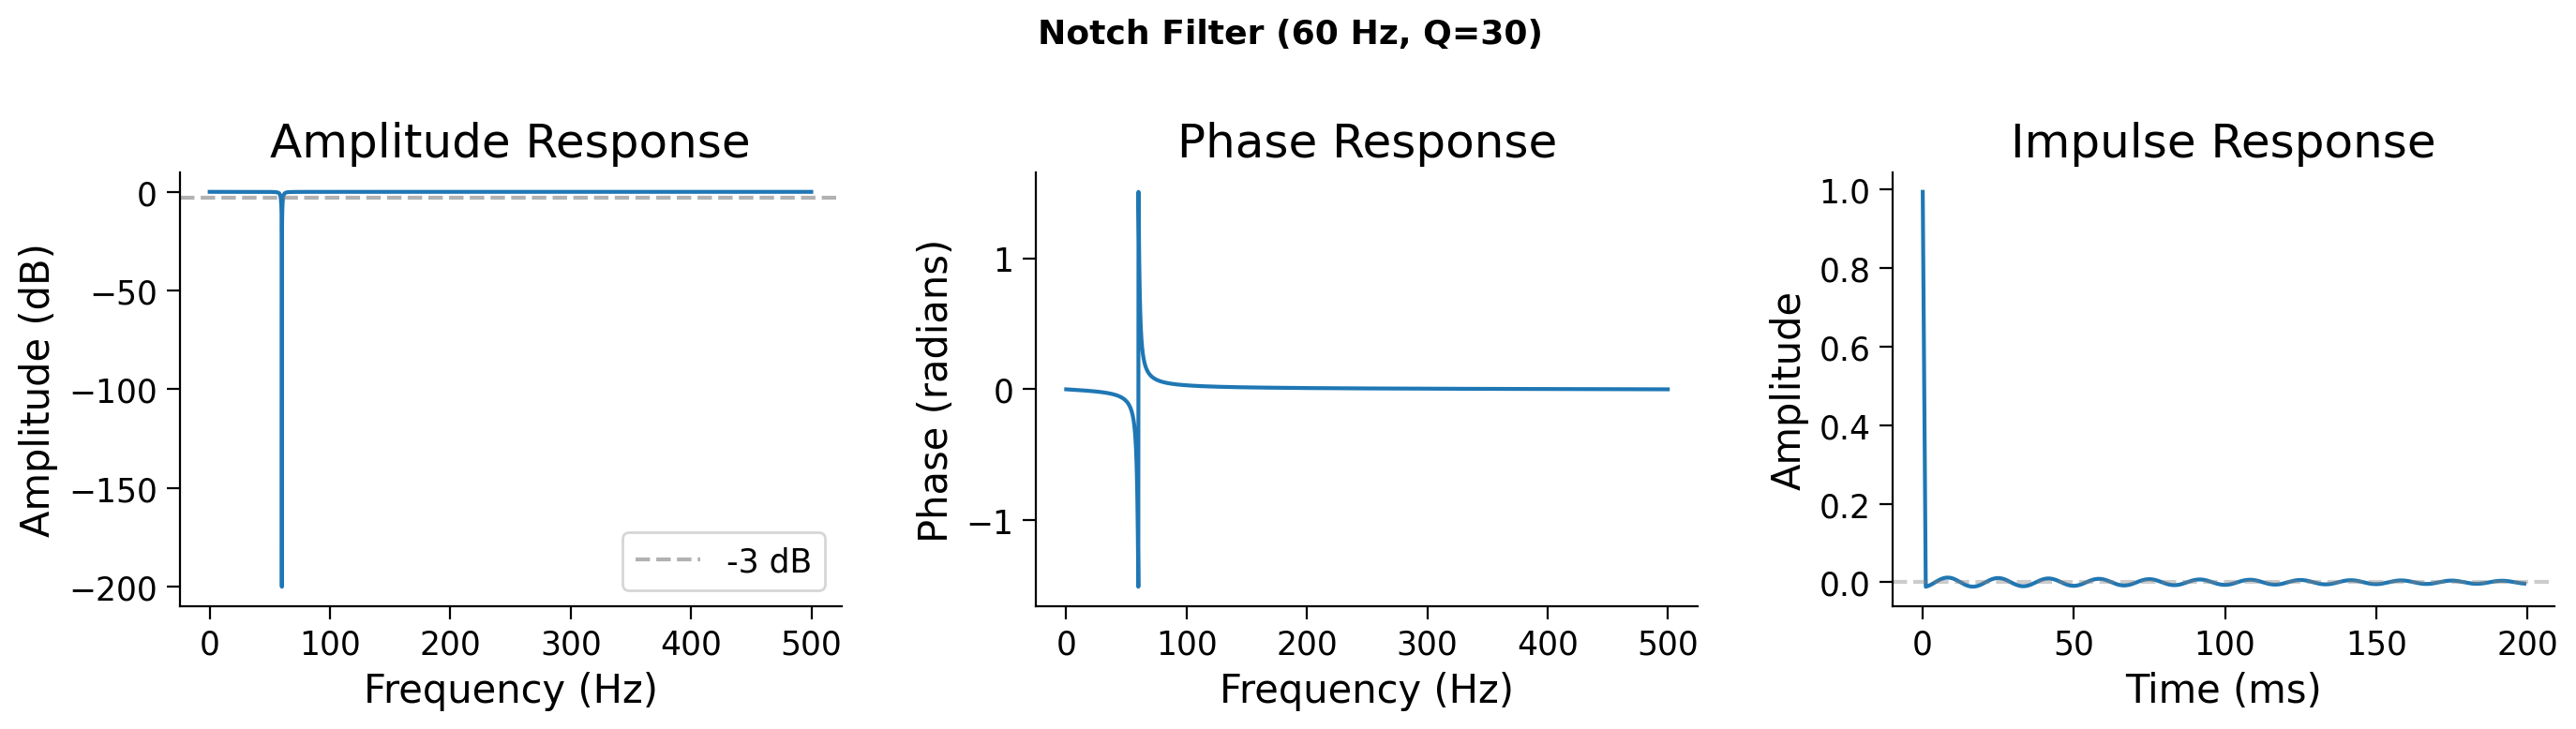

In [6]:
fs = 1000.0  # Hz

# Low-pass: keep below 30 Hz
b_lp, a_lp = signal.butter(4, 30.0, btype='low', fs=fs)
plot_filter_responses(b_lp, a_lp, fs, "4th-order Butterworth Low-pass (30 Hz)")

# High-pass: keep above 300 Hz
b_hp, a_hp = signal.butter(4, 300.0, btype='high', fs=fs)
plot_filter_responses(b_hp, a_hp, fs, "4th-order Butterworth High-pass (300 Hz)")

# Band-pass: 4–80 Hz
b_bp, a_bp = signal.butter(4, [4.0, 80.0], btype='band', fs=fs)
plot_filter_responses(b_bp, a_bp, fs, "4th-order Butterworth Band-pass (4–80 Hz)")

# Notch: remove 60 Hz
b_notch, a_notch = signal.iirnotch(60.0, Q=30, fs=fs)
plot_filter_responses(b_notch, a_notch, fs, "Notch Filter (60 Hz, Q=30)")

---

### **A note on filter design: Butterworth and beyond**

In these examples we use **Butterworth filters**—a solid default choice because they have a **maximally flat passband** (no ripple) and a **smooth, monotonic roll‑off**. However, Butterworth is just one member of a broader family of classic filter designs, each making different tradeoffs:

- **Butterworth** — flat passband, gentle roll‑off. The filter used in this tutorial.  
- **Chebyshev I / II** — sharper roll‑off than Butterworth, but with ripple (in the passband for Type I, stopband for Type II).  
- **Elliptic (Cauer)** — the steepest roll‑off of all, with ripple in *both* bands.  
- **Bessel** — maximally flat **group delay** (minimal phase distortion), but the shallowest roll‑off.

The essential tradeoff to remember:  
**Sharper frequency‑domain transitions → longer, more oscillatory impulse responses → more ringing.**

Filter design is a deep field, but for practical analysis the key is simply knowing **what compromises your chosen filter makes** and whether those compromises matter for your data. `scipy.signal` implements all of the above (`cheby1`, `ellip`, `bessel`) if you want to explore alternatives.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_FilterTypes")

---

# Section 3: Convolution

*Estimated timing to here from start of tutorial: 5 min*

Filters work by combining each sample of the input signal with nearby samples in a specific pattern. The mathematical operation behind this is **convolution**.

In [ ]:
# @title Video 2: The theory behind filtering

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'glXz1tlayiA'), ('Bilibili', 'BV1eRTz6WEZj')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_2_Theory")

## From impulse to any input

Any discrete signal can be re-written as a sum of shifted, scaled impulses:

$$x[n] = \sum_k x[k] \, \delta[n - k]$$

There's nothing special here: we simply re-write the signal as a "spike" or impulse at each time point, scaled by the value of the signal at that time. This is basically also what happens when you sample the continuous signal at discrete time points, i.e., in Tutorial 1, like the lollipop plot.

Now let's consider a filter, which is a linear time-invariant (LTI) system, with an impulse response $h[n]$ (right column of the plots above). This $h[n]$ is the output of the system when the input is a single impulse $\delta[n]$, and is often referred to as the **kernel** of the system.

For a *linear* system, the output for each impulse component is $x[k] \cdot h[n-k]$.

For a *time-invariant* system, i.e., the response is the same at all times, the impulse response just shifts.

Adding them all up gives us **convolution**:

$$(x * h)[n] = \sum_k x[k] \, h[n - k]$$

In words: flip the filter kernel (or impulse response) $h$, slide it across the signal $x$, and at each position compute the dot product. The result is the output of the LTI system.


  1. **Flip** $h[m] \to h[-m]$.
  2. **Shift** to get $h[n-m]$ (the index $n$ is the output time step).
  3. **Multiply** pointwise with $x[m]$.
  4. **Sum** over $m$ — the total is $y[n]$.

## Interactive Demo 1: Convolution step by step

Make sure you execute this cell to enable the widget!

In [7]:
# @title Visualization: Convolution step by step

def plot_convolution_steps(step=0):
    fs = 1000.0
    n = 200

    # Simple input: two pulses
    x = np.zeros(n)
    x[40:60] = 1.0  # first pulse
    x[100:110] = 0.6  # second pulse

    # Kernel: leaky integrator
    kernel_len = 60
    t_k = np.arange(kernel_len) / fs
    h = leaky_integrator_response(t_k, tau=0.01)
    h = h / h.sum()  # normalize

    # Full convolution
    y_full = np.convolve(x, h, mode='full')[:n]

    # Flipped kernel at current position
    t = np.arange(n) / fs

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Input signal
    axes[0].fill_between(t * 1000, x, alpha=0.6, color='C0')
    axes[0].set_ylabel("x[n]")
    axes[0].set_title("Input signal")

    # Flipped kernel at position
    h_flipped = h[::-1]
    kernel_positions = np.arange(step - kernel_len + 1, step + 1)
    valid = (kernel_positions >= 0) & (kernel_positions < n)
    axes[1].fill_between(t * 1000, 0, 0, alpha=0.3, color='C1')
    if np.any(valid):
        pos_valid = kernel_positions[valid]
        h_valid = h_flipped[valid]
        axes[1].bar(pos_valid / fs * 1000, h_valid, width=1.0,
                    color='C1', alpha=0.6)
    axes[1].set_ylabel("h[n-k]")
    axes[1].set_title(f"Flipped kernel at position n={step}")

    # Output so far
    axes[2].plot(t[:step+1] * 1000, y_full[:step+1], 'C2', lw=2)
    axes[2].plot(t * 1000, y_full, 'C2', lw=1, alpha=0.2)
    axes[2].set_ylabel("(x * h)[n]")
    axes[2].set_title("Convolution output")
    axes[2].set_xlabel("Time (ms)")
    axes[2].set_xlim(0, n / fs * 1000)

    plt.tight_layout()
    plt.show()

interact(plot_convolution_steps,
         step=widgets.IntSlider(value=0, min=0, max=180, step=5,
                                description="Position n"));

interactive(children=(IntSlider(value=0, description='Position n', max=180, step=5), Output()), _dom_classes=(…

As you slide the kernel across the input, notice how each pulse in the input produces a "smeared" copy of the impulse response in the output. This is exactly what convolution does — it replaces each input sample with a scaled copy of the kernel.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_2_Convolution")

## Coding Exercise 1: Convolve different signals with a kernel

Use `np.convolve` to convolve three different input signals with a Gaussian kernel. Plot each input and its convolution output.

**Steps:**
1. Create a Gaussian kernel using `signal.windows.gaussian()`
2. Convolve each input signal with the kernel using `np.convolve(..., mode='full')`
3. Plot the results

In [11]:
# @title Execute this cell to set up the example

# Defining some constants
fs = 1000.0
n = 500
t = np.arange(n) / fs

# Three input signals
x_pulse = np.zeros(n); x_pulse[200:220] = 1.0   # rectangular pulse
x_sine = np.sin(2 * np.pi * 10 * t)              # 10 Hz sine
rng = np.random.default_rng(42)
x_noisy = np.sin(2 * np.pi * 5 * t) + 0.8 * rng.standard_normal(n)  # noisy sine

# Gaussian kernel (51 samples wide, std=10 samples)
gauss_kernel = signal.windows.gaussian(51, std=10)
gauss_kernel = gauss_kernel / gauss_kernel.sum()  # normalize to sum to 1

In [19]:
###################################################################
## TODO for students:
## 1. Convolve x_pulse with gauss_kernel using np.convolve(..., mode='full')
## 2. Convolve x_sine with gauss_kernel
## 3. Convolve x_noisy with gauss_kernel
## Store results in y_pulse, y_sine, y_noisy
## Then trim each to length n: y = y[:n]
###################################################################

y_pulse = np.convolve(x_pulse, gauss_kernel, mode = 'full')[:n]
y_sine =  np.convolve(x_sine, gauss_kernel, mode = 'full')[:n]
y_noisy =  np.convolve(x_noisy, gauss_kernel, mode = 'full') [:n]

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_4bac5bcb.py)

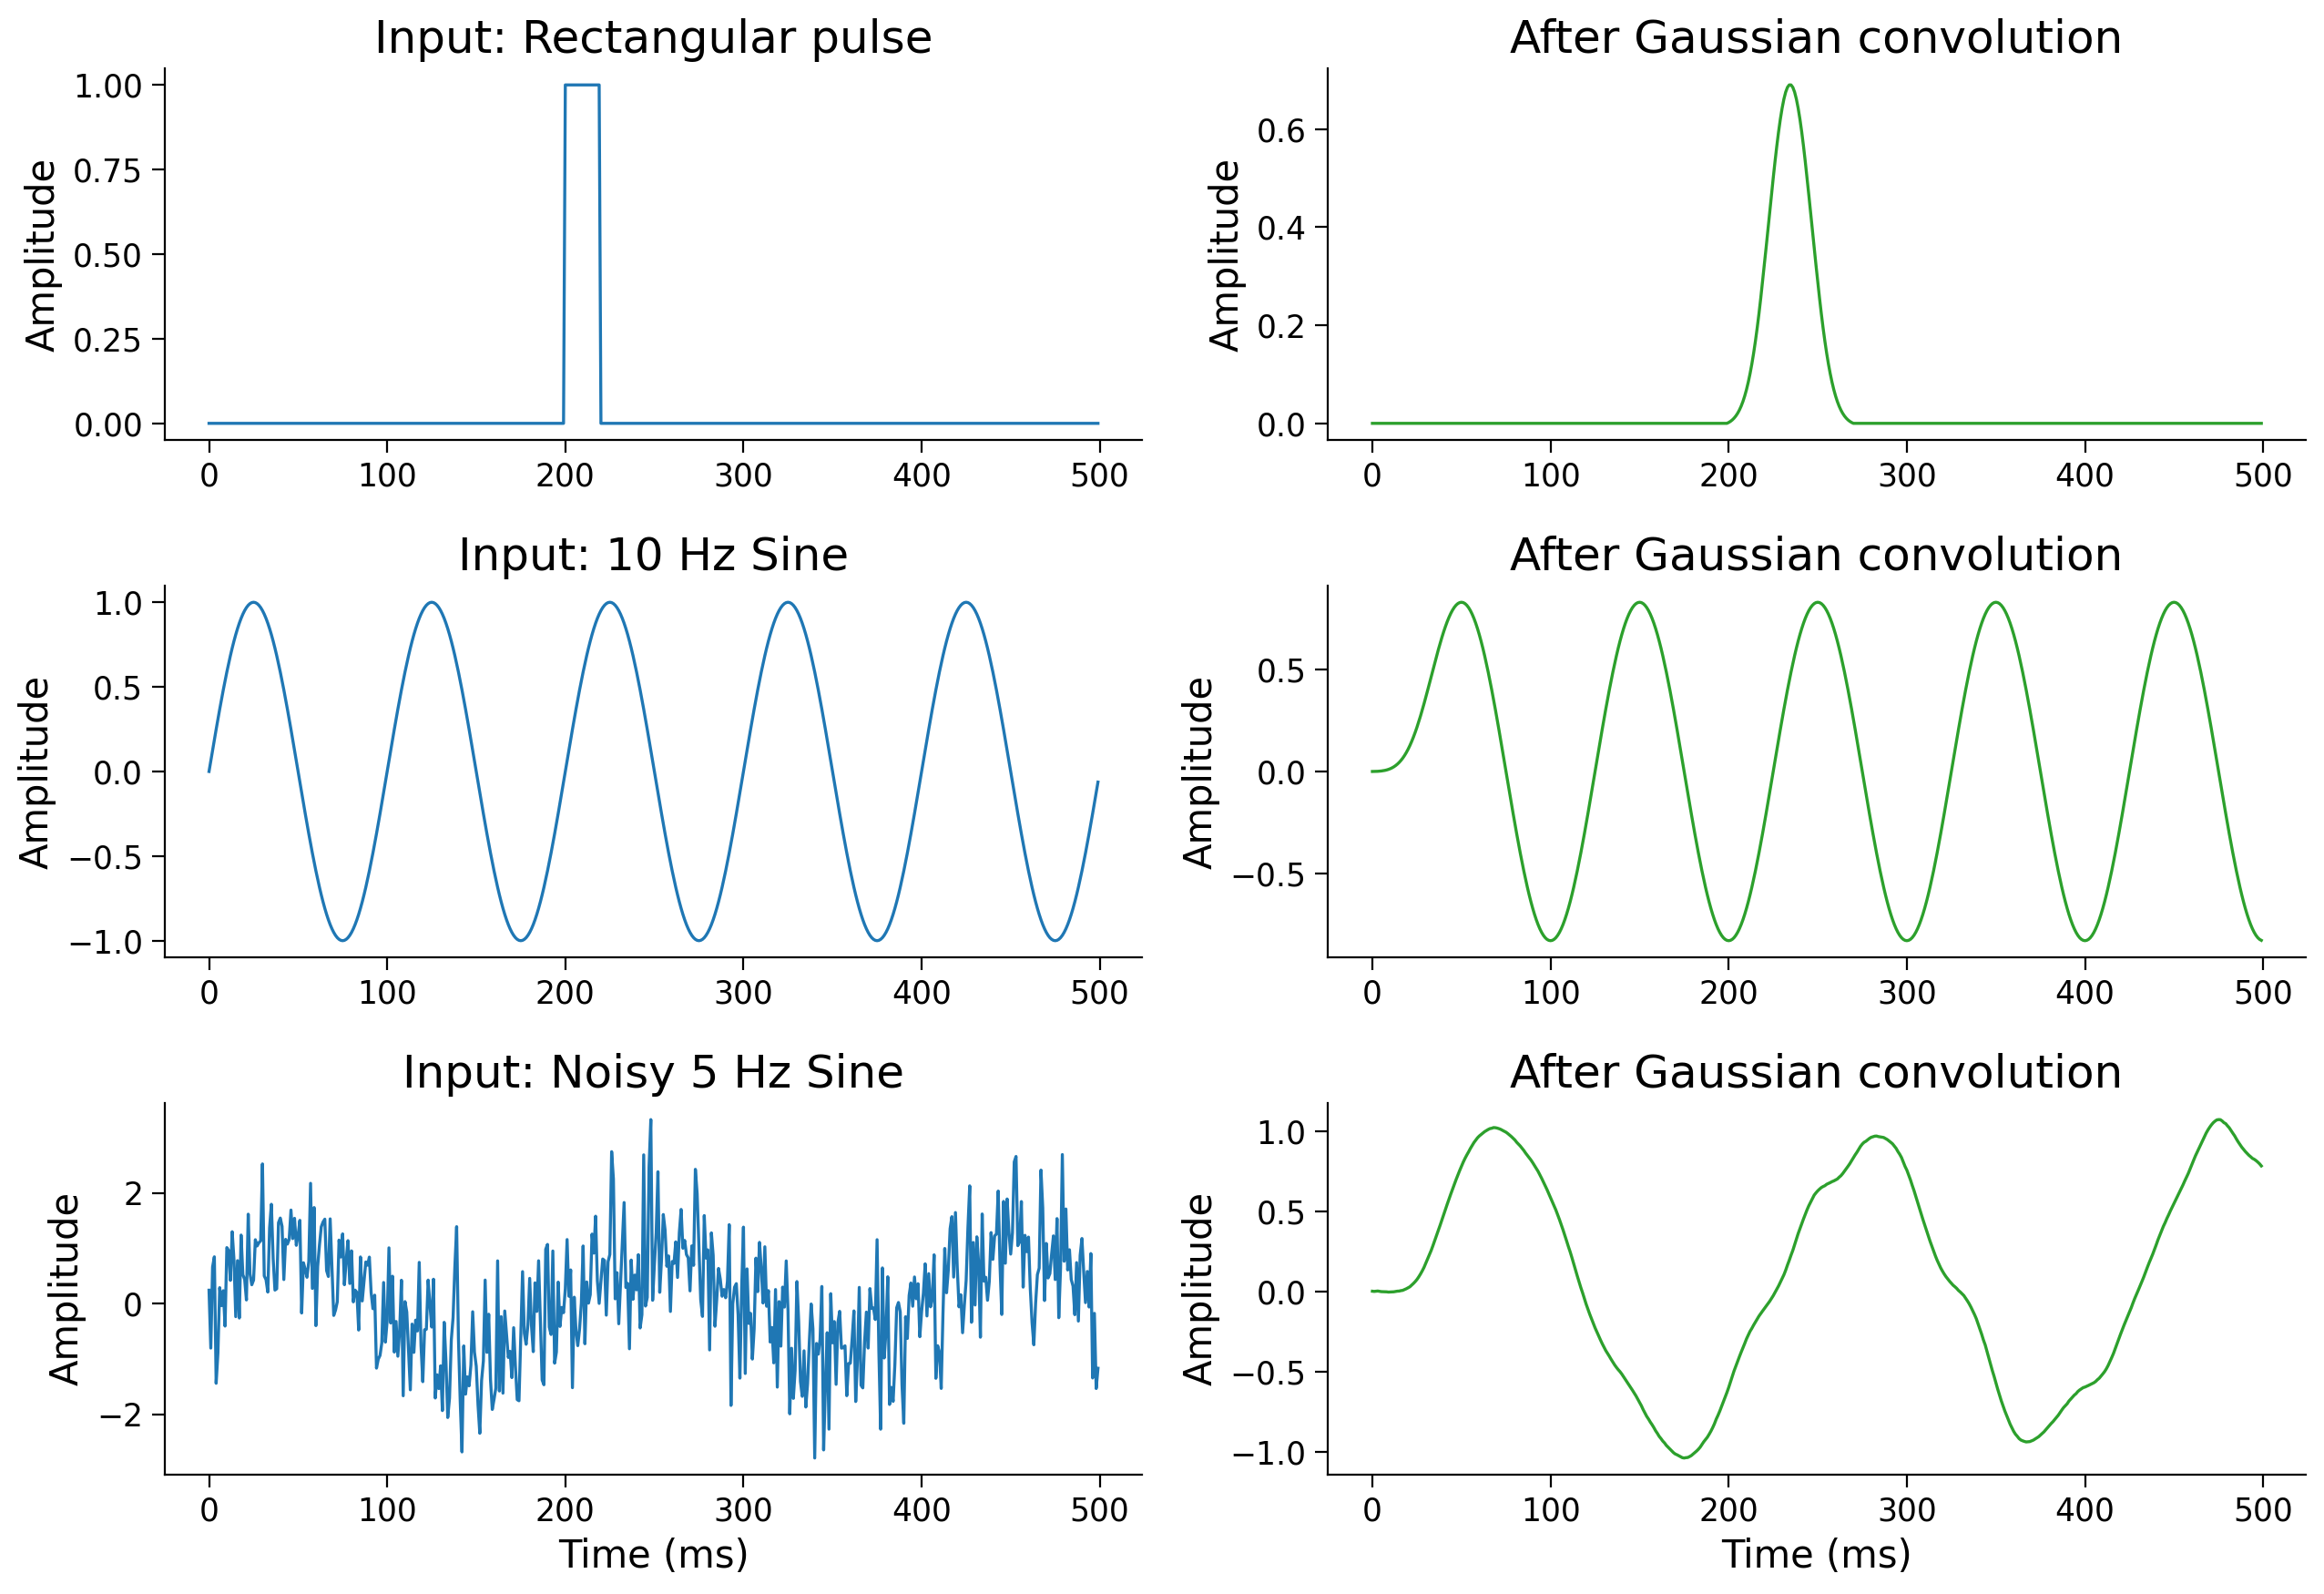

In [20]:
# Plotting (runs after you haved fill in the above)
inputs = [("Rectangular pulse", x_pulse, y_pulse),
          ("10 Hz Sine", x_sine, y_sine),
          ("Noisy 5 Hz Sine", x_noisy, y_noisy)]
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for i, (name, x_in, y_out) in enumerate(inputs):
    axes[i, 0].plot(t * 1000, x_in, 'C0', lw=1.2)
    axes[i, 0].set_title(f"Input: {name}")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 1].plot(t * 1000, y_out, 'C2', lw=1.2)
    axes[i, 1].set_title(f"After Gaussian convolution")
    axes[i, 1].set_ylabel("Amplitude")
axes[2, 0].set_xlabel("Time (ms)")
axes[2, 1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_1_Convolution")

## Think! 1: Convolution effects

1. What happened to the sharp edges of the rectangular pulse after convolution?
2. Did the 10 Hz sine change much? Why or why not? (Hint: think about the frequency content of the Gaussian kernel.)
3. What happened to the noise in the noisy sine? Why is convolution with a Gaussian sometimes called "smoothing"?

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_36e5fb6a.py)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Think_1_Convolution")

---

*Estimated timing to here from start of tutorial: 15 min*

## LTI systems: why convolution is the right tool

A filter is a **Linear Time-Invariant (LTI) system**. Linear means that scaling or adding inputs scales or adds outputs. Time-invariant means the system behaves the same regardless of when the input arrives.

The key is that, if you know how an LTI system responds to a single **impulse** (a delta function), you know *everything* about how it responds to *any* input. This response is called the **impulse response**, typically written as $h(t)$. The output of this system to *any* input $x(t)$ is their **convolution**.

A classic example from neuroscience is the **leaky integrator**, where $h(t) = \frac{1}{\tau} e^{-t/\tau}$ for $t \geq 0$. The time constant $\tau$ controls how quickly the system forgets past input. This is the "kernel" in Demo 1.

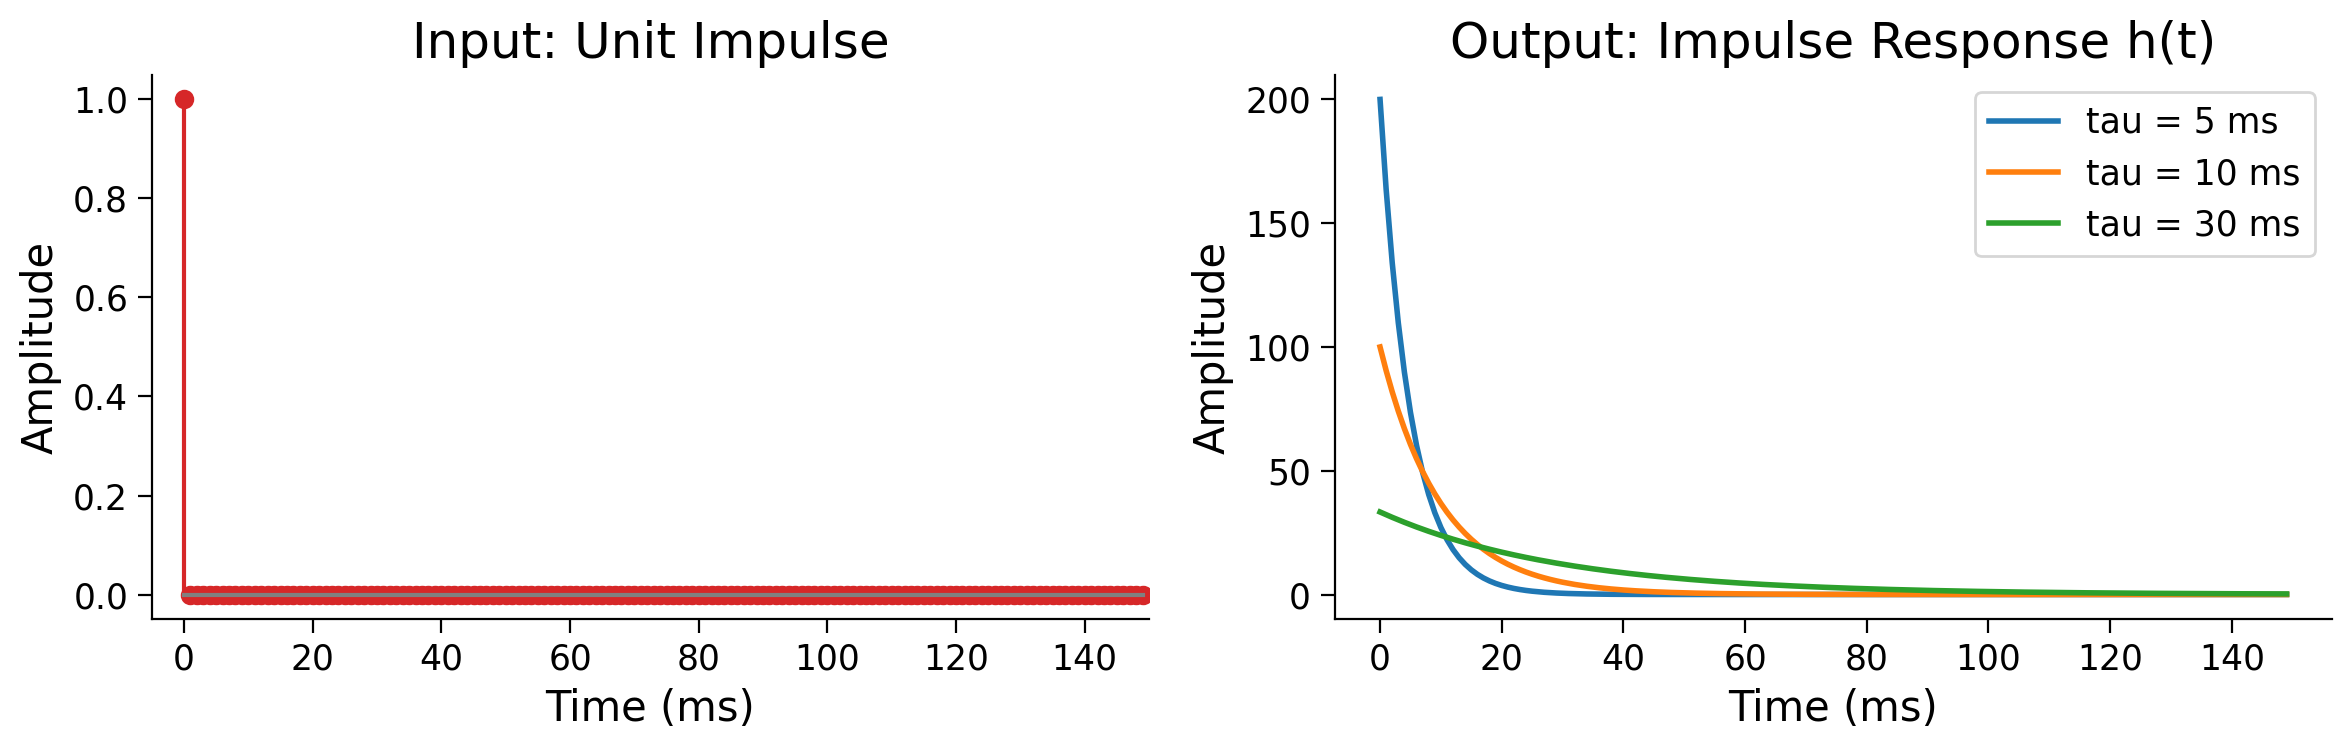

In [21]:
# Demo: Impulse response of a leaky integrator

fs = 1000.0  # Hz
duration = 0.15  # seconds
t = np.arange(0, duration, 1.0 / fs)

# Create an impulse at t=0
impulse = make_impulse(len(t), position=0)

# Compute impulse responses for different time constants
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(t * 1000, impulse, linefmt='C3-', markerfmt='C3o', basefmt='gray')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Input: Unit Impulse')
axes[0].set_xlim(-5, 150)

for tau in [0.005, 0.01, 0.03]:
    h = leaky_integrator_response(t, tau)
    axes[1].plot(t * 1000, h, lw=2, label=f'tau = {tau*1000:.0f} ms')

axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Output: Impulse Response h(t)')
axes[1].legend()
plt.tight_layout()
plt.show()

A short time constant (small $\tau$) means rapid decay, while a long time constant means the system integrates over a longer window. This is the same tradeoff you face in filter design: how much temporal context should the filter consider?

---

# Section 4: The Convolution Theorem

*Estimated timing to here from start of tutorial: 18 min*

Computing convolution sample by sample *in time-domain* is expensive. But there is an elegant shortcut, and it reveals deep structure about how LTI systems work.

**The Convolution Theorem** states:

$$\mathcal{F}\{x * h\} = \mathcal{F}\{x\} \cdot \mathcal{F}\{h\}$$

where $x * h$ is the convolution of $x$ and $h$, and $\mathcal{F}$ denotes the Fourier transform.

**Convolution in the time domain is equivalent to pointwise multiplication in the frequency domain** (and vice versa).

This means: to understand what an LTI system does to a signal, you can simply look at how it *multiplies* each frequency component. This is the foundation of filter design (Section 5).

## Key Fourier Transform Pairs

A **Fourier pair** is a precise identity: a function with parameters in the time-domain transforms into a specific function whose parameters are rearranged in the frequency-domain.

| Time domain $x(t)$ | Frequency domain $X(f)$ | Why it matters |
|---|---|---|
| $\delta(t)$ (impulse) | $1$ (flat — all frequencies equal) | A single spike contains every frequency equally |
| Gaussian, std $\sigma_t$  | Gaussian, std $\frac{1}{2\pi\sigma_t}$  | Smoothing in time = smooth attenuation in frequency; width inverts ($\sigma_t \uparrow \Rightarrow \sigma_f \downarrow$) (remember Tutorial 2) |
| Rectangle of width $T$ (boxcar)| Sinc with first zero at $1/T$ | Sharp cutoffs in time create ringing in frequency |
| Dirac comb, spacing $T$ | Dirac comb, spacing $1/T$ | This *is* sampling  |

---

## Coding Exercise 2: Verify the Convolution Theorem

The convolution theorem says that convolution in time equals multiplication in frequency. Let's check this numerically.

**Steps:**
1. Convolve `x_noisy` with `gauss_kernel` in the time domain using `np.convolve`
2. Compute the same result in the frequency domain: take the FFT of both signals, multiply them pointwise, then inverse FFT
3. Compare the two results — they should be identical (up to numerical precision)

**Hint:** For the frequency-domain approach, you need both signals to have the same length. "Zero-pad" both to `n + len(gauss_kernel) - 1` before taking the FFT.

In [30]:
# Signal and kernel from Exercise 1
# x_noisy is already defined (noisy 5 Hz sine, length n=500)
# gauss_kernel is already defined (length 51)

conv_length = len(x_noisy) + len(gauss_kernel) - 1  # length of full convolution

###################################################################
## TODO for students:
## 1. Compute y_time: convolve x_noisy with gauss_kernel (mode='full')
##
## 2. Compute y_freq using the frequency domain:
##    a. Zero-pad both signals to conv_length
##       x_padded = np.zeros(conv_length); x_padded[:len(x_noisy)] = x_noisy
##       h_padded = np.zeros(conv_length); h_padded[:len(gauss_kernel)] = gauss_kernel
##    b. Take FFT of both: np.fft.rfft(...)
##    c. Multiply the FFTs pointwise
##    d. Inverse FFT: np.real(np.fft.irfft(...))
##
## 3. Compare the two results
###################################################################

# 1. Time-domain convolution
y_time = np.convolve(x_noisy, gauss_kernel, mode = 'full')

# 2. Frequency-domain convolution
x_padded = np.zeros(conv_length)
x_padded[:len(x_noisy)] = x_noisy
h_padded = np.zeros(conv_length)
h_padded[:len(gauss_kernel)] = gauss_kernel
X_freq = np.fft.rfft(x_padded)
H_freq = np.fft.rfft(h_padded)
y_freq = np.real(np.fft.irfft(X_freq * H_freq))

max_diff = np.max(np.abs(y_time - y_freq))
print(f"Max difference: {max_diff:.2e}")

Max difference: 6.66e-16


[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_769b7eae.py)

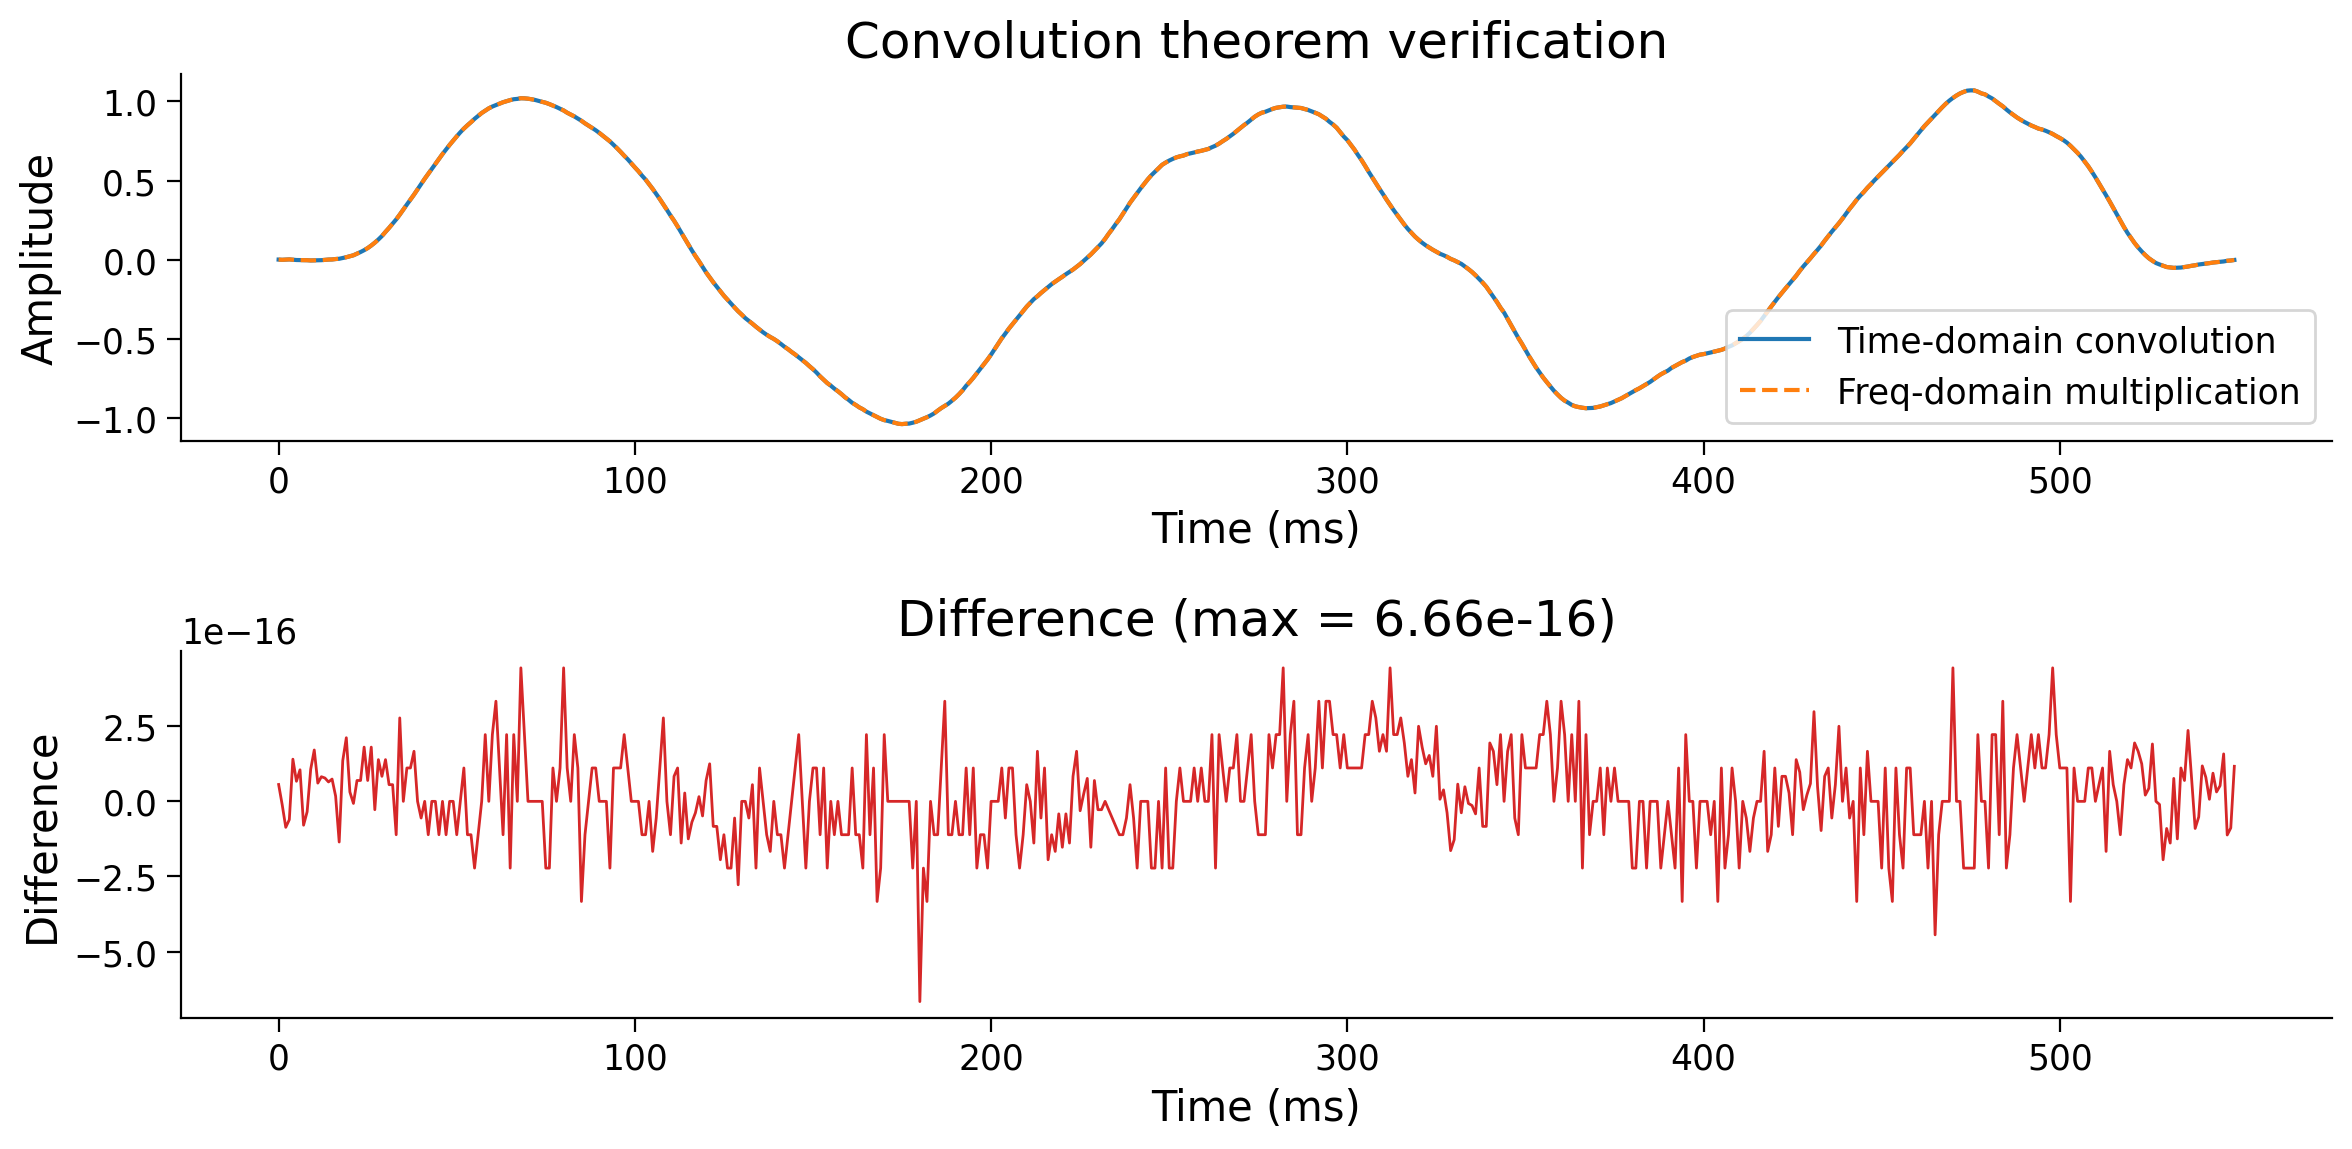

In [31]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
t_conv = np.arange(conv_length) / fs
ax1.plot(t_conv * 1000, y_time, "C0", lw=1.5, label="Time-domain convolution")
ax1.plot(t_conv * 1000, y_freq, "C1--", lw=1.5, label="Freq-domain multiplication")
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Amplitude")
ax1.set_title("Convolution theorem verification")
ax1.legend()

ax2.plot(t_conv * 1000, y_time - y_freq, "C3", lw=1)
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Difference")
ax2.set_title(f"Difference (max = {max_diff:.2e})")
ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
plt.tight_layout()
plt.show()

The difference should be on the order of $10^{-15}$ — essentially zero (floating-point precision). The two methods give the same result because they are mathematically equivalent!

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_2_ConvTheorem")

---
# Section 5: Filter design and pitfalls

*Estimated timing to here from start of tutorial: 26 min*

In [ ]:
# @title Video 3: Filter design and pitfalls

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents

video_ids = [('Youtube', 'QH36Rnwz40k'), ('Bilibili', 'BV1eRTz6WEp6')]
tab_contents = display_videos(video_ids, W=854, H=480)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_3_Pitfalls")

Why not just use a perfect rectangular (boxcar) filter in frequency? It would pass exactly the frequencies we want and nothing else.

A *boxcar* (or rectangular window) in frequency is simply a filter that is *1 inside the passband* and *0 outside*. In other words, it keeps a band of frequencies perfectly untouched and deletes everything else.

> **Recall from Section 4** (Convolution Theorem - Key Fourier Transform Pairs): a boxcar of width $T$ in the time domain corresponds to a sinc with first zero at $1/T$ in frequency - and the same identity runs *in reverse*:
>
> A boxcar *in frequency* corresponds to a sinc *in time*. That single row of the Fourier pairs table is the reason the ideal filter fails in practice.

The sinc function
$$
\text{sinc}(t) = \frac{\sin(\pi t)}{\pi t}
$$
has two key problems that make it unusable as a filter kernel:

1. **Infinite support**: It extends from $-\infty$ to $+\infty$, impossible on a finite recording  
2. **Non-causal**: It is non-zero for $t < 0$, meaning it requires future data

Try adjusting the cutoff in the demo below and watch what happens to the sinc kernel in time - the narrower the passband, the longer and more oscillatory the kernel becomes. This is the Fourier uncertainty principle at work, and it is the core tradeoff we'll keep returning to throughout this section.

## Interactive Demo 2: Ideal filter — frequency vs. time tradeoff

Make sure you execute this cell to enable the widget!

In [32]:
# @title Interactive Demo: Ideal Filter - Frequency vs. Time Tradeoff

def plot_filter_tradeoff(cutoff_fraction=0.1):
    N = 1000
    freqs = np.fft.rfftfreq(N)
    H_ideal = (freqs < cutoff_fraction).astype(float)
    h_time = np.fft.fftshift(np.fft.irfft(H_ideal))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(freqs, H_ideal, color='C1', lw=2)
    axes[0].fill_between(freqs, 0, H_ideal, alpha=0.2, color='C1')
    axes[0].set_xlabel("Normalised frequency")
    axes[0].set_title(f"Ideal Filter (Boxcar) - cutoff={cutoff_fraction:.2f}")

    axes[1].plot(h_time, color='C2', lw=1.5)
    axes[1].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[1].set_xlabel("Sample index (centred)")
    axes[1].set_title("Impulse Response (Sinc) - note the ringing!")
    axes[1].annotate("Extends to ±∞", xy=(400, 0.02), color='gray', fontsize=9)
    plt.suptitle("Ideal in Frequency = Problematic in Time", fontweight='bold')
    plt.tight_layout(); plt.show()

interact(plot_filter_tradeoff,
         cutoff_fraction=widgets.FloatSlider(min=0.02, max=0.4, step=0.02,
                                             value=0.1, description='Cutoff'));

interactive(children=(FloatSlider(value=0.1, description='Cutoff', max=0.4, min=0.02, step=0.02), Output()), _…

When interacting with the visualization, you'll notice that as you make the `cutoff` narrower, the sinc kernel in time becomes **wider** and rings for longer. This is the Fourier uncertainty principle: sharp frequency selectivity requires a long time-domain kernel. Real filters need to navigate this tradeoff.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_2_IdealFilter")

## Causal vs. non-causal filters

Butterworth filters solve the problems of the ideal boxcar by giving us a stable, well‑behaved kernel. But even with a good filter design, how we apply it matters just as much as the design itself.

This brings us to a crucial distinction: whether the filter is allowed to use future samples (non-causal) or must operate strictly in real time (causal).

A **causal** filter only uses past and present samples - required for real-time systems like BCIs.

A **non-causal** (zero-phase) filter also uses samples from the future. Since we usually process recordings after the fact, this is allowed - and it eliminates "phase distortion" (as we will see).

The most common approach is **zero-phase filtering** (`scipy.signal.filtfilt`): apply the filter forward then backward, which doubles the effective order but cancels all phase shifts.

| | Causal (`lfilter`) | Zero-phase (`filtfilt`) |
|---|---|---|
| Prevents phase distortion | ✗ No | ✔ Yes |
| Usable in real-time | ✔ Yes | ✗ No |
| Effective filter order | N | 2N |

### Why does phase distortion matter in neuroscience?

Neuroscience often studies *relationships* between signals - the phase of a theta oscillation relative to a gamma burst, or the timing of a spike relative to a stimulus.

When you use a causal filter, you introduce a *frequency-dependent time shift* (i.e., phase distortion): different frequencies are delayed by different amounts. That means the temporal relationship between your filtered signal and another signal (or the original event) is corrupted *simply by the filter itself*.

If you study the timing of gamma bursts relative to theta phase, a causal filter's phase shift can produce false conclusions about whether one leads or lags the other. **Use `filtfilt` (zero-phase) for offline analysis whenever temporal precision matters.**

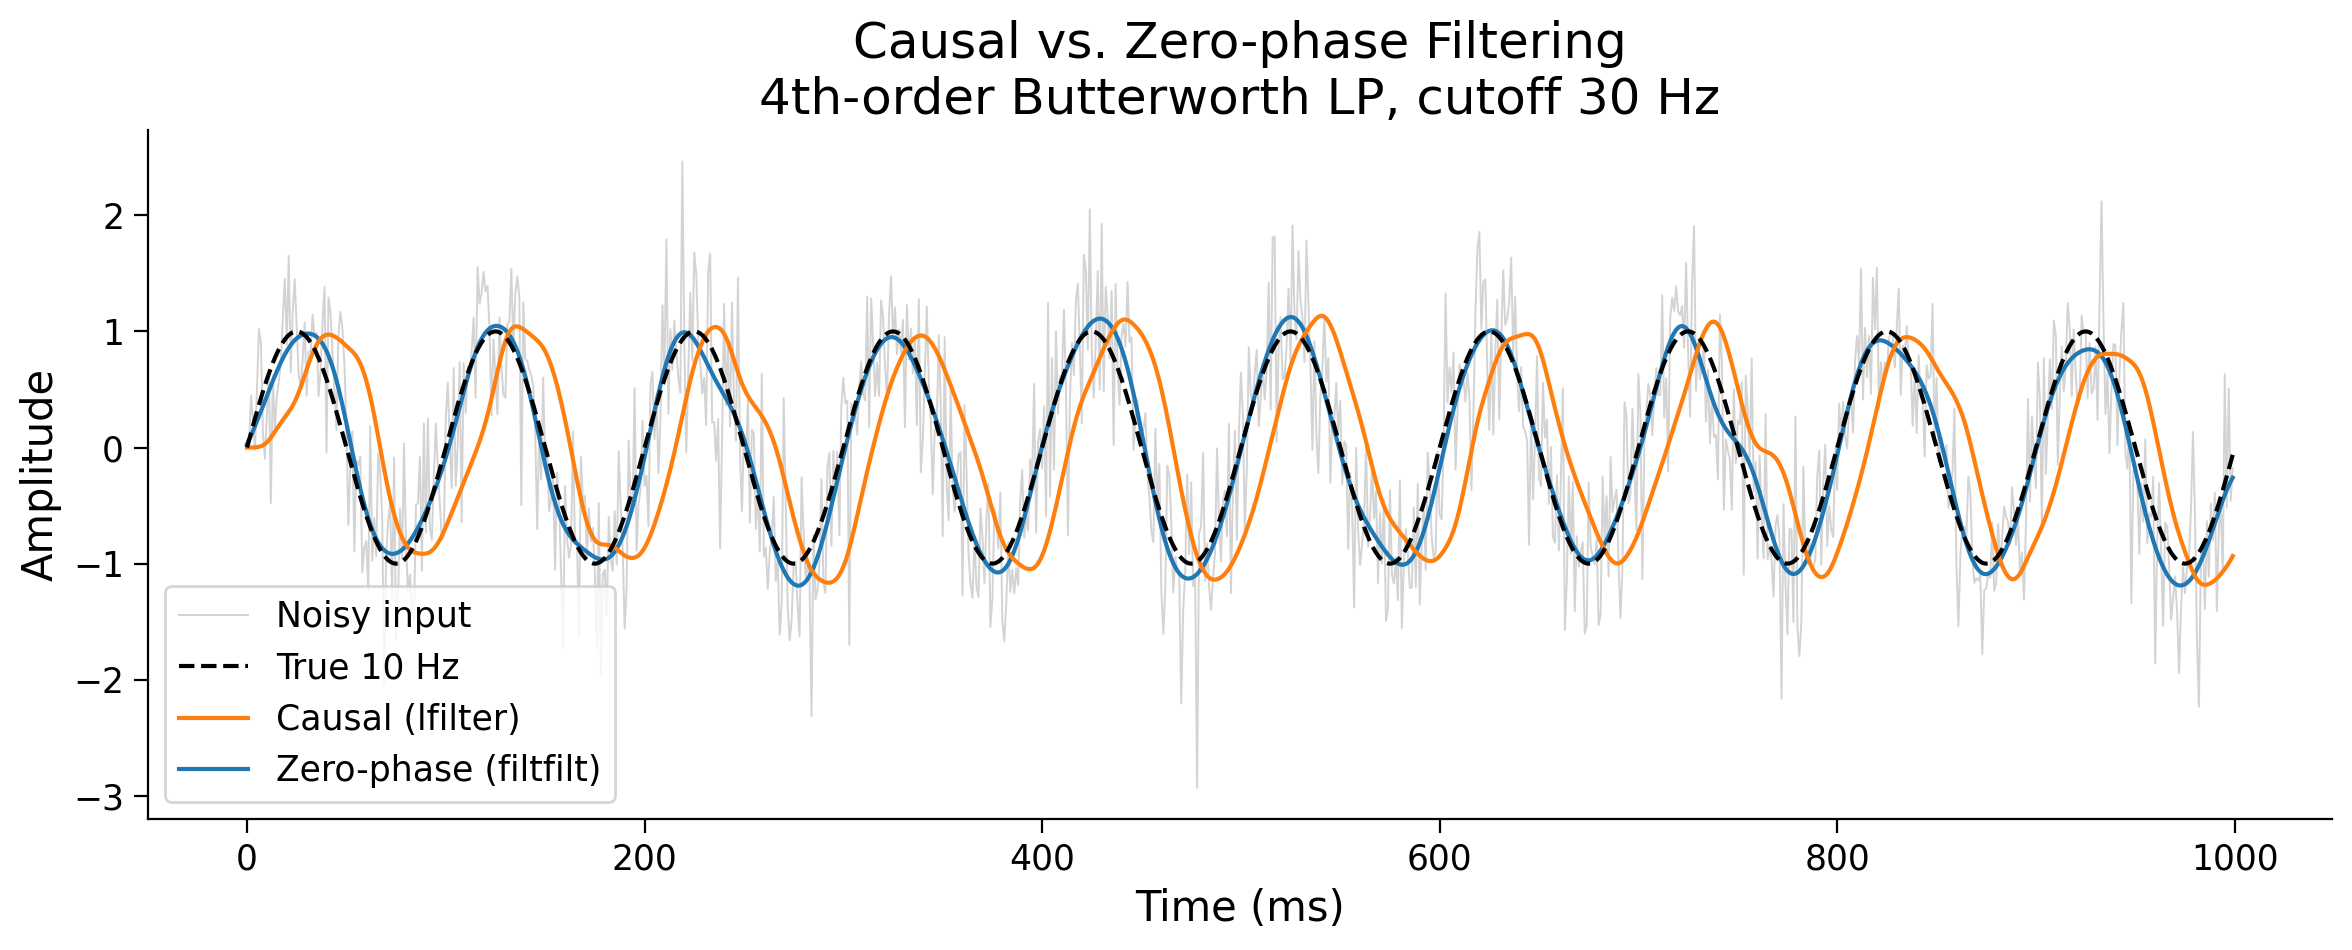

In [33]:
fs = 1000.0
t  = np.arange(0, 1.0, 1/fs)
x_clean = np.sin(2 * np.pi * 10 * t)
rng = np.random.default_rng(0)
x_noisy = x_clean + 0.5 * rng.standard_normal(len(t))

b, a = signal.butter(4, 30.0, btype='low', fs=fs)
x_causal    = signal.lfilter(b, a, x_noisy)
x_zerophase = signal.filtfilt(b, a, x_noisy)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t*1000, x_noisy,     color='lightgray', lw=0.7, label='Noisy input',          zorder=1)
ax.plot(t*1000, x_clean,     color='black',     lw=1.5, label='True 10 Hz',  ls='--', zorder=4)
ax.plot(t*1000, x_causal,    color='C1',        lw=1.5, label='Causal (lfilter)',      zorder=3)
ax.plot(t*1000, x_zerophase, color='C0',        lw=1.5, label='Zero-phase (filtfilt)', zorder=2)
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Amplitude")
ax.set_title("Causal vs. Zero-phase Filtering\n4th-order Butterworth LP, cutoff 30 Hz")
ax.legend()
plt.tight_layout(); plt.show()

Notice the phase lag in the causal output - peaks arrive later than in the true signal.

> **When to use causal vs. zero-phase:** For online/real-time systems (BCIs, closed-loop experiments) causal filtering is *required* - you literally don't have future samples.
>
> For offline analysis of stored recordings, zero-phase (`filtfilt`) is almost always preferable.

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_CausalFilters")

## Filtering dos and don'ts

*Estimated timing to here from start of tutorial: 35 min*

Filtering done poorly can:

a) **Throw out real signal** - a cutoff too aggressive removes features you care about

b) **Create temporal distortions** - phase shifts move events in time

c) **Introduce ringing** - the sinc-like impulse response creates oscillatory artifacts around transients

d) **Create phantom oscillations** - the most insidious artifact in LFP analysis. Any broadband signal (a spike, or even plain 1/f noise) that contains power across many frequencies will, after narrow band-pass filtering, produce an oscillatory output. That output is not a neural oscillation - it is the filter's own impulse response ringing.

For example, band-pass filtering a spike produces an apparent "gamma burst" that is nothing but a filtering artifacts - and band-pass filtering background 1/f noise can produce apparent rhythms that don't exist. Let's see why.

First, let's start with a question: What is the spectrum of a perfect impulse (delta function) that we could consider?

$$
\mathcal{F}\{\delta(t)\} = 1
$$

It is *flat* - equal power at every frequency. If we band-pass filter a spike, we multiply a flat spectrum by our filter's passband and get a pure oscillation at the filter's center frequency.

In other words, that oscillation was *never in the data* - it is entirely a product of our filter's impulse response. This is true for white noise as well (remember Tutorial 2's phase randomization Demo).

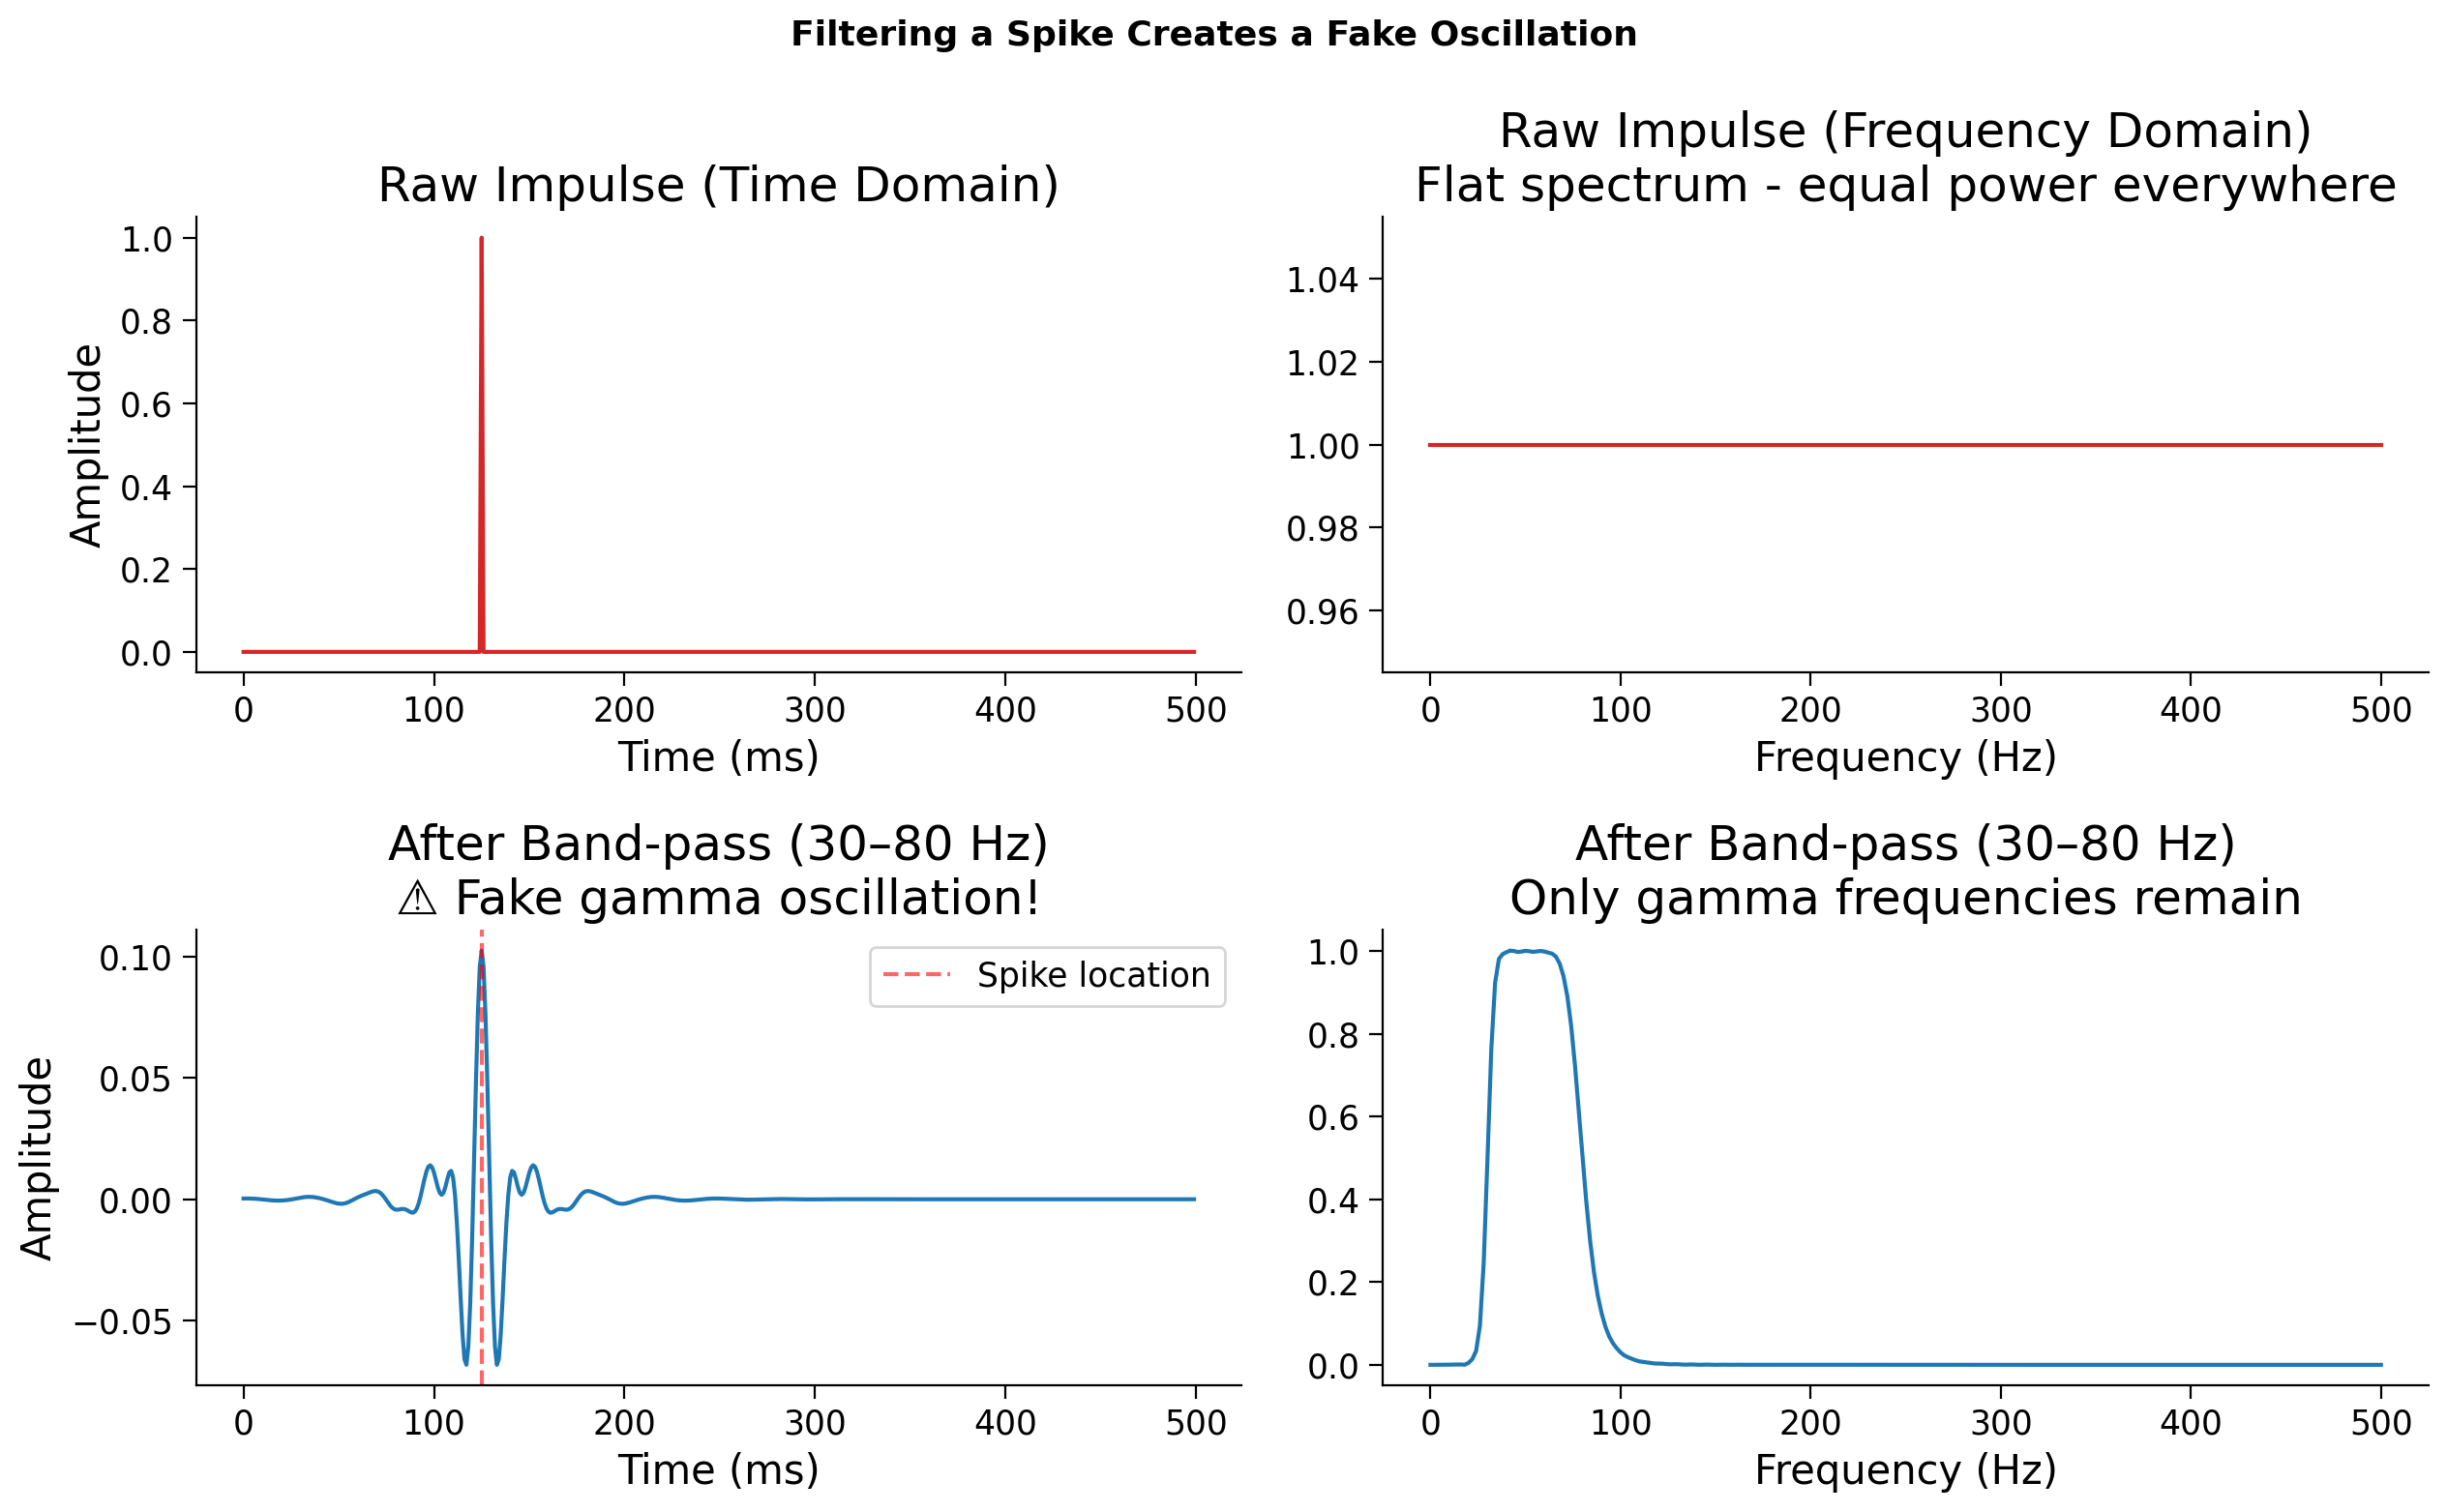

In [34]:
fs = 1000.0
n  = 500
t  = np.arange(n) / fs
spike = make_impulse_at_quarter(n_samples=n)

b_gamma, a_gamma = signal.butter(4, [30.0, 80.0], btype='band', fs=fs)
spike_filtered   = signal.filtfilt(b_gamma, a_gamma, spike)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(t*1000, spike, color='C3', lw=1.5)
axes[0,0].set_title("Raw Impulse (Time Domain)")
axes[0,0].set_xlabel("Time (ms)"); axes[0,0].set_ylabel("Amplitude")

freqs = np.fft.rfftfreq(n, 1/fs)
axes[0,1].plot(freqs, np.abs(np.fft.rfft(spike)), color='C3')
axes[0,1].set_title("Raw Impulse (Frequency Domain)\nFlat spectrum - equal power everywhere")
axes[0,1].set_xlabel("Frequency (Hz)")

axes[1,0].plot(t*1000, spike_filtered, color='C0', lw=1.5)
axes[1,0].axvline(t[n//4]*1000, color='red', ls='--', alpha=0.6, label='Spike location')
axes[1,0].set_title("After Band-pass (30–80 Hz)\n⚠ Fake gamma oscillation!")
axes[1,0].set_xlabel("Time (ms)"); axes[1,0].set_ylabel("Amplitude")
axes[1,0].legend()

axes[1,1].plot(freqs, np.abs(np.fft.rfft(spike_filtered)), color='C0')
axes[1,1].set_title("After Band-pass (30–80 Hz)\nOnly gamma frequencies remain")
axes[1,1].set_xlabel("Frequency (Hz)")

plt.suptitle("Filtering a Spike Creates a Fake Oscillation", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

The top row shows a raw impulse, a single spike in time, and its flat spectrum. Because a delta function contains all frequencies equally, it’s the most broadband signal possible.  

Now look at the bottom row. When we apply a **band‑pass filter (30-80 Hz)**, we’re multiplying that flat spectrum by the filter’s passband. Only gamma‑range frequencies survive, and when we transform back to the time domain, those frequencies combine into a short oscillation around the spike.  

That oscillation looks like a "gamma burst," but it’s an artifact of the filter’s impulse response, and not a real rhythm in the data.

In practice, this means that apparent oscillations near sharp transients (e.g., spikes or edges) should always be treated with caution, and **understanding our filter’s frequency response matters!**

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_DosAndDonts")

---

# Section 6: Hands-on with real Neuropixels data

*Estimated timing to here from start of tutorial: 40 min*

In [35]:
# @title Load IBL Neuropixels Data - Streams directly from DANDI (run me first!)
# Streams 2 seconds from subject DY-008, channel 60 (best LFP+spike channel)
# No large download needed - remfile fetches only the bytes we ask for.
!pip install remfile h5py --quiet
import remfile, h5py

url  = 'https://api.dandiarchive.org/api/assets/604b7457-430e-4160-b7ff-594562d942e3/download/'
f    = h5py.File(remfile.File(url), 'r')
ap   = f['acquisition']['ElectricalSeriesProbe00AP']

ap_fs  = 30000.0       # Hz, confirmed from timestamps
conv   = 2.34375e-06   # to volts
BEST_CH = 60           # channel with clearest LFP structure + spikes
T_DUR   = 2.0          # seconds to stream
i1      = int(T_DUR * ap_fs)
t_ap    = np.arange(i1) / ap_fs

print(f'Streaming {T_DUR}s from channel {BEST_CH} at {ap_fs} Hz...')
# Contiguous slice required by remfile - [:, CH:CH+1] not [:, CH]
raw_ap  = ap['data'][:i1, BEST_CH:BEST_CH+1].astype(float)[:, 0] * conv * 1e6  # µV
raw_ap  = raw_ap - np.mean(raw_ap)  # zero-centre
print(f'Done. Shape: {raw_ap.shape}, duration: {t_ap[-1]:.2f}s')
print(f'Signal range: {raw_ap.min():.1f} to {raw_ap.max():.1f} µV')

Streaming 2.0s from channel 60 at 30000.0 Hz...
Done. Shape: (60000,), duration: 2.00s
Signal range: -344.4 to 185.3 µV


Now we apply everything to a real snippet of extracellular recording.

The data comes from the **International Brain Laboratory (IBL)** -- the same recording you explored in Tutorial 2 -- a Neuropixels probe recording from a mouse during a decision-making task (DANDI:000409, subject DY-008).

Neuropixels probes record **broadband** signals simultaneously from hundreds of channels. The same raw voltage trace contains both slow LFP activity and fast spike transients - and the way you separate them is by filtering. This is *exactly what happens* at the start of every extracellular electrophysiology analysis pipeline.

> **Recall from Tutorial 2:** You've already seen power spectra on real EEG data. The exercise below applies the same idea to Neuropixels LFP - notice whether the 1/f structure looks similar or different across recording modalities.

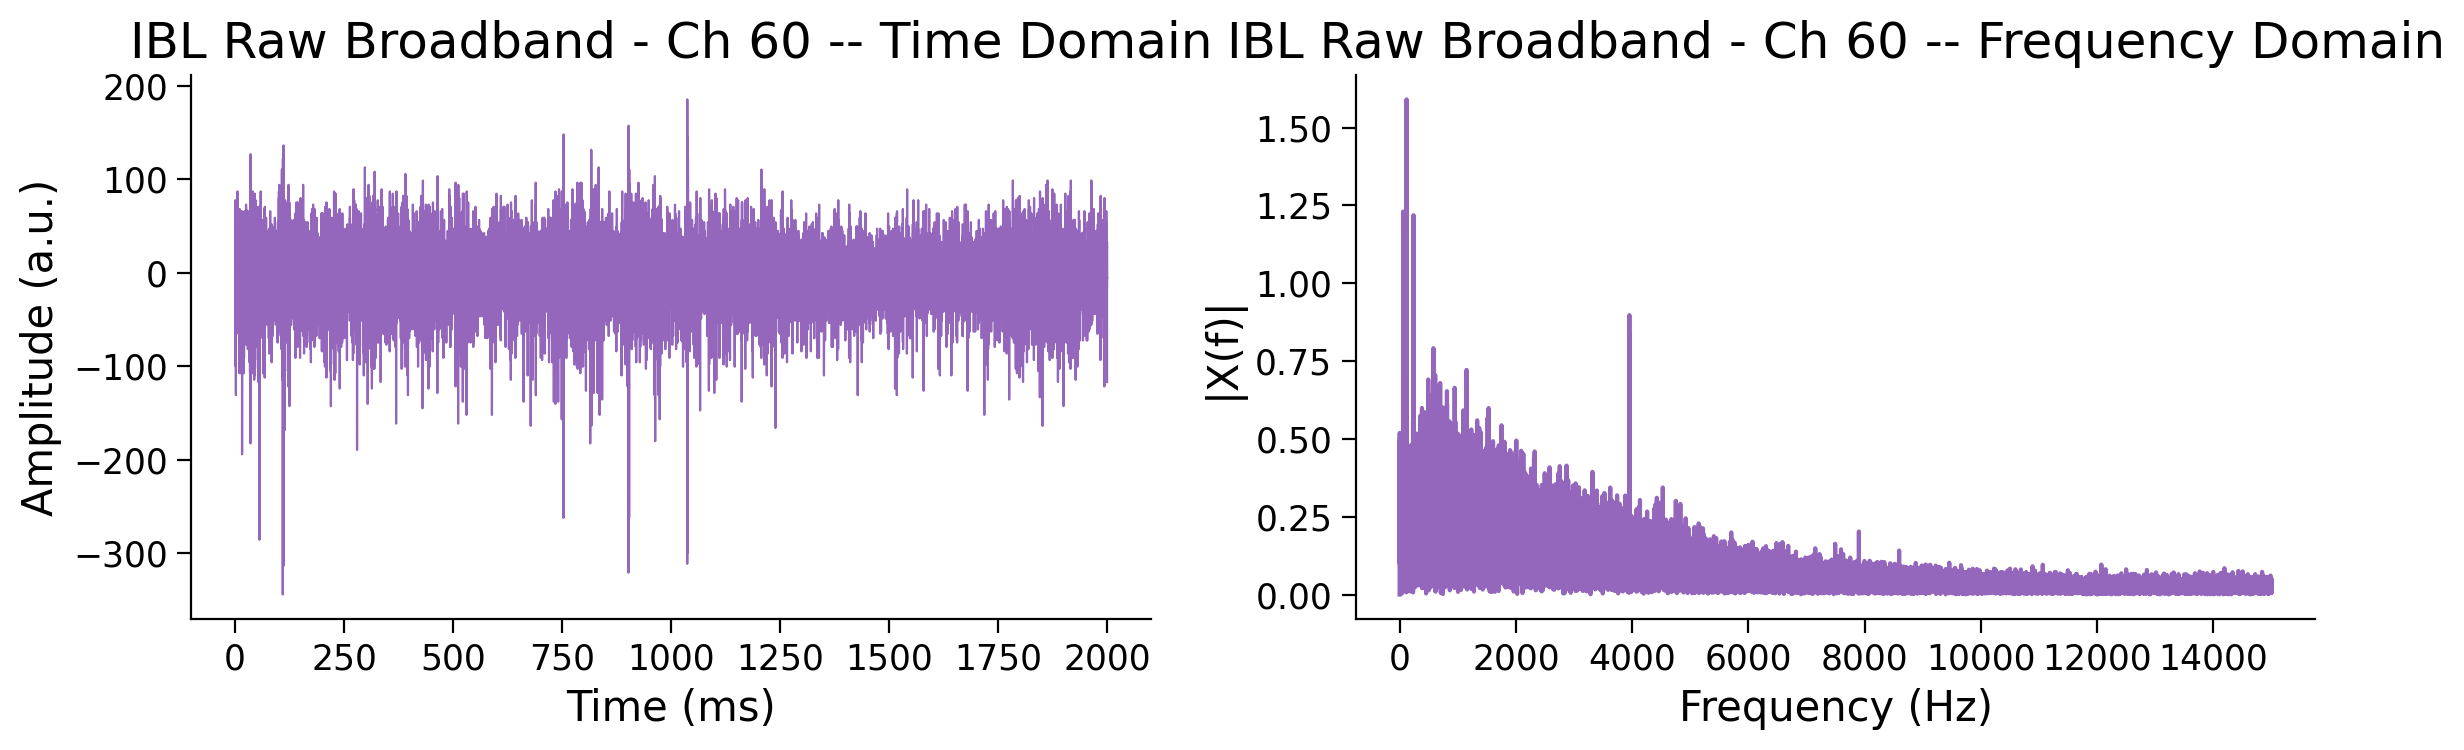

Duration: 2.0s | Sampling rate: 30000.0 Hz | Units: µV


In [36]:
plot_signal_and_spectrum(t_ap, raw_ap, ap_fs,
                         title=f'IBL Raw Broadband - Ch {BEST_CH}',
                         color='C4')
print(f'Duration: {t_ap[-1]:.1f}s | Sampling rate: {ap_fs} Hz | Units: µV')

## Coding Exercise 3: Separate LFP and spikes from the raw recording

The first step in extracellular electrophysiology pipelines is to apply filters on the raw recording.

**Steps:**

Apply two filters to `raw_ap`:
1. A **low-pass** filter to extract the LFP (keep below 300 Hz)
2. A **high-pass** filter to extract the spike band (keep above 300 Hz)

**Note:** The IBL AP data is sampled at 30,000 Hz - you can use `ap_fs` as your sampling rate. Signal amplitude is already in µV.

In [40]:
###################################################################
## TODO for students:
## 1. Design a low-pass Butterworth filter (cutoff 300 Hz, order 4)
##    and apply it zero-phase to `raw_ap`. Store in `ibl_lfp_band`.
## 2. Design a high-pass Butterworth filter (cutoff 300 Hz, order 4)
##    and apply it zero-phase to `raw_ap`. Store in `ibl_spike_band`.
###################################################################

b_lp, a_lp = signal.butter(4, 300.0, btype='low', fs = ap_fs)
b_hp, a_hp = signal.butter(4, 300.0, btype='high', fs = ap_fs)
ibl_lfp_band  = signal.filtfilt(b_lp, a_lp, raw_ap)
ibl_spike_band = signal.filtfilt(b_hp, a_hp, raw_ap)

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_a27401c6.py)

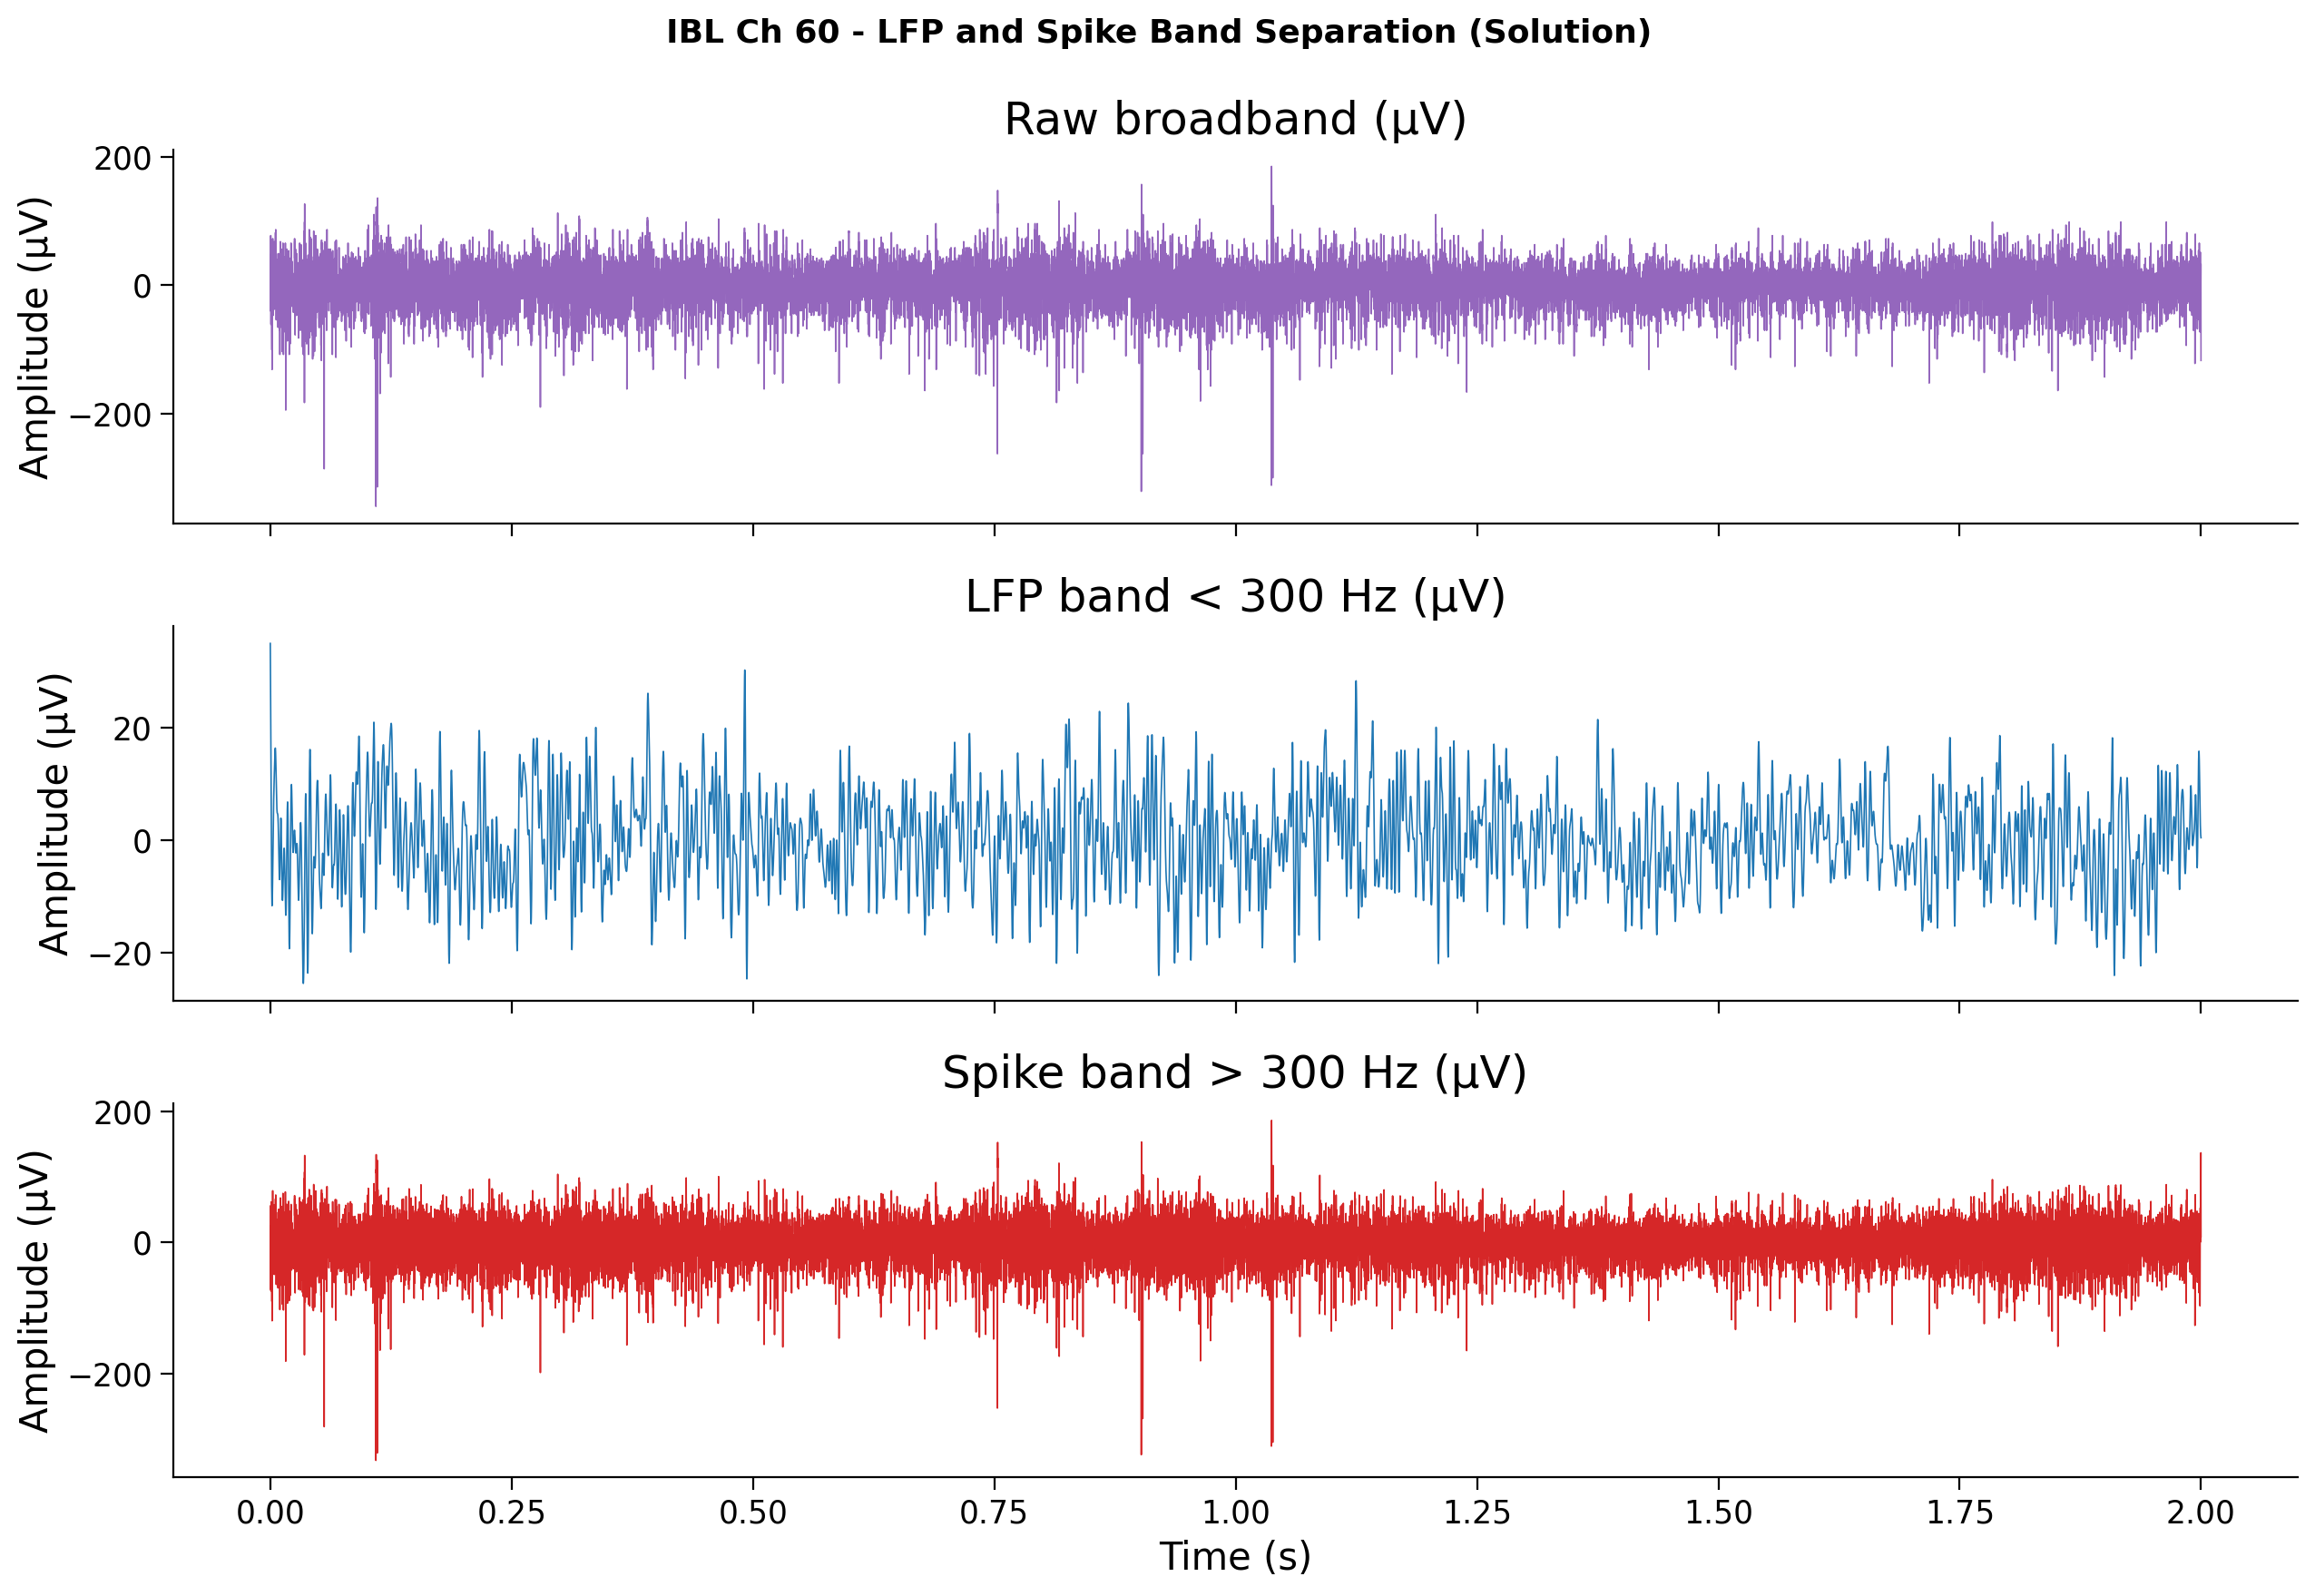

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, sig, label, color in zip(
    axes,
    [raw_ap, ibl_lfp_band, ibl_spike_band],
    ['Raw broadband (µV)', 'LFP band < 300 Hz (µV)', 'Spike band > 300 Hz (µV)'],
    ['C4', 'C0', 'C3']
):
    ax.plot(t_ap, sig, color=color, lw=0.6)
    ax.set_ylabel('Amplitude (µV)')
    ax.set_title(label)
    axes[-1].set_xlabel('Time (s)')

plt.suptitle(f'IBL Ch {BEST_CH} - LFP and Spike Band Separation (Solution)',
                fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

From here, we can analyze our LFP band data, or threshold the spike band to start detecting putative action potentials!

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_3_LFPSpikes")

---

# Summary

*Estimated timing of tutorial: 45 minutes*

In this tutorial we learned that:

- **Filters** isolate specific frequency components of a signal (low-pass, high-pass, band-pass, notch)
- **Convolution** is the mathematical operation that implements filtering: flip the kernel, slide it across the signal
- Any filter is a **Linear Time-Invariant (LTI) system**, fully described by its impulse response
- The **convolution theorem** connects time and frequency: convolution in time equals multiplication in frequency
- Real filter design involves tradeoffs: sharp cutoffs create ringing, causal filters introduce delay
- Common pitfalls: filtering a spike creates fake oscillations, aggressive filtering removes real signal

In [ ]:
# @title Submit your feedback on this tutorial
content_review(f"{feedback_prefix}_Summary")

---

# Bonus Material

The sections below contain additional material that extends the core tutorial. They are optional but highly recommended!

If you have time before the next tutorial or want to come back at the end of the day, these sections will help you explore the material in more depth.

---

# Bonus 1: LTI systems — full treatment

This section provides the complete interactive exploration of LTI systems, including coding exercises to implement convolution from scratch and verify linearity and time-invariance.

## What makes a system LTI?

An LTI system has two properties:

**Linear:** If the input is scaled by a constant, the output scales by
the same constant. If two inputs are added together, the output is the
sum of the individual outputs.

$$\text{If } x(t) \to y(t), \text{ then } a \cdot x(t) \to a \cdot y(t)$$
$$\text{If } x_1(t) \to y_1(t) \text{ and } x_2(t) \to y_2(t),
\text{ then } x_1(t) + x_2(t) \to y_1(t) + y_2(t)$$

**Time-invariant:** Delaying the input by some amount simply delays the
output by the same amount -- the system does not change over time.

$$\text{If } x(t) \to y(t), \text{ then } x(t - t_0) \to y(t - t_0)$$

## Why does this matter?

Here is the key insight: if you know how an LTI system responds to a
single **impulse** (a delta function), you know *everything* about how
it responds to *any* input. This response is called the **impulse
response**, typically written as $h(t)$. The output to any input $x(t)$
is their **convolution** (we will explore other convolutions):

$$y(t) = (x * h)(t) = \int_{-\infty}^{\infty} x(\tau)\, h(t-\tau)\, d\tau$$

In the following exercises we will work with sampled signals, so we approximate this
integral with the discrete form:

$$y[n] = \Delta t \sum_{m=0}^{M-1} x[n-m] \, h[m]$$

A classic example from neuroscience is the **leaky integrator** -- a
simple model of how a neuron's membrane potential decays exponentially
after receiving a brief input. Its impulse response is
$h(t) = \frac{1}{\tau} e^{-t/\tau}$ for $t \geq 0$.

A short time constant (small $\tau$) means rapid decay -- the system
"forgets" quickly. A long time constant means the system integrates
over a longer window of past input.

In [ ]:
# Impulse response of a leaky integrator

fs = 1000.0  # Hz
duration = 0.15  # seconds
t = np.arange(0, duration, 1.0 / fs)

# Create an impulse at t=0
impulse = make_impulse(len(t), position=0)

# Compute impulse responses for different time constants
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(t * 1000, impulse, linefmt='C3-', markerfmt='C3o', basefmt='gray')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Input: Unit Impulse')
axes[0].set_xlim(-5, 150)

for tau in [0.005, 0.01, 0.03]:
    h = leaky_integrator_response(t, tau)
    axes[1].plot(t * 1000, h, lw=2, label=f'tau = {tau*1000:.0f} ms')

axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Output: Impulse Response h(t)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Bonus Coding Exercise: Build an LTI system and verify its properties

Implement the discrete convolution sum from above in `apply_system`
below. The outer loop walks over output time $n$; the inner loop
accumulates the contribution from each kernel sample $h[m]$ looking
$m$ samples back in $x$.

When your implementation is correct, the test will:
1. Numerically verify linearity and time-invariance
2. Plot both properties so you can see them directly

In [ ]:
def apply_system(x, h, dt):
    """Compute the LTI output y = x * h via the direct convolution sum.

    Parameters
    ----------
    x  : array, shape (N,)
        Input signal.
    h  : array, shape (M,)
        Impulse response.
    dt : float
        Sampling interval (seconds).

    Returns
    -------
    y  : array, shape (N,)
        Output signal, same length as x.
    """
    N, M = len(x), len(h)
    y = np.zeros(N)

    for n in range(N):
        for m in range(min(n + 1, M)):
            ###############################################################
            ## TODO for students: complete the two lines below.
            raise NotImplementedError('Student exercise: implement the convolution sum')
            ###############################################################

            # Multiply the input m steps back by the m-th kernel sample
            contribution = ...

            # Accumulate into the output (don't forget the dt factor)
            y[n] = ...

    return y

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_7e79e925.py)

In [ ]:
def test_and_plot_lti(apply_system, dt=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    N = 500
    t = np.arange(N) * dt

    # Impulse response: causal exponential decay
    tau = 0.05
    h = np.exp(-t / tau) * (t >= 0)

    # --- Linearity test ---
    x1 = rng.standard_normal(N)
    x2 = rng.standard_normal(N)
    a, b = 1.7, -0.4

    y1 = apply_system(x1, h, dt)
    y2 = apply_system(x2, h, dt)
    y_sum = apply_system(a * x1 + b * x2, h, dt)
    lin_err = np.max(np.abs(y_sum - (a * y1 + b * y2)))

    # --- Time-invariance test ---
    k = 23
    x1_shift = np.roll(x1, k)
    x1_shift[:k] = 0
    y1_shift = apply_system(x1_shift, h, dt)
    expected = np.roll(y1, k)
    expected[:k] = 0
    ti_err = np.max(np.abs(y1_shift - expected))

    print(f'Linearity error    : {lin_err:.2e}')
    print(f'Time-inv. error    : {ti_err:.2e}')
    assert lin_err < 1e-10, 'Linearity violated!'
    assert ti_err  < 1e-10, 'Time-invariance violated!'
    print('Looks like an LTI system.')

    # --- Visual verification ---
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Linearity panel: T{a*x1 + b*x2} vs a*T{x1} + b*T{x2}
    axes[0].plot(t * 1000, y_sum, 'C0', lw=2,
                 label='T{a x1 + b x2}')
    axes[0].plot(t * 1000, a * y1 + b * y2, 'C1--', lw=2,
                 label='a T{x1} + b T{x2}')
    axes[0].set_xlabel('Time (ms)')
    axes[0].set_title(f'Linearity (error = {lin_err:.1e})')
    axes[0].legend(fontsize=9)

    # Time-invariance panel: shift input vs shift output
    axes[1].plot(t * 1000, y1_shift, 'C0', lw=2,
                 label=f'Response to shifted input (+{k} ms)')
    axes[1].plot(t * 1000, expected, 'C1--', lw=2,
                 label=f'Shifted response (should match)')
    axes[1].set_xlabel('Time (ms)')
    axes[1].set_title(f'Time-invariance (error = {ti_err:.1e})')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

test_and_plot_lti(apply_system)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_Bonus_LTI")

## Think! LTI properties

1. When you scale the input by 3×, does the output scale by exactly 3×? What about the shape — does it change?
2. When you shift the input, does the output shape change or just translate?
3. Can you think of a biological system that would *not* be LTI? (Hint: think about neurons that fire action potentials.)

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_289e6f71.py)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Think_LTI")

---

# Bonus 2: Fourier transform pairs

Key Fourier pairs build intuition for the convolution theorem. Each pair shows what a signal looks like in both time and frequency.

## Fourier Transform Pairs

In [ ]:
# @title Fourier Transform Pairs

n = 1024
fs = 1000.0
t = (np.arange(n) - n // 2) / fs
freqs = np.fft.rfftfreq(n, 1.0 / fs)

pairs = [
    ("Delta", make_impulse(n, position=n // 2),
     "Flat spectrum (all frequencies)"),

    ("Gaussian (sigma = 5 ms)",
     np.exp(-t**2 / (2 * 0.005**2)) / np.exp(-t**2 / (2 * 0.005**2)).max(),
     "Gaussian in frequency"),

    ("Boxcar (100 samples wide)",
     np.where(np.abs(t) <= 50 / fs, 1.0, 0.0),
     "Sinc -- note the sidelobes"),

    ("Dirac comb (spacing = 50 samples)",
     np.where(np.arange(n) % 50 == 0, 1.0, 0.0),
     f"Dirac comb (spacing = {fs / 50:.0f} Hz)"),

    ("Step function",
     np.where(np.arange(n) >= n // 2, 1.0, 0.0),
     "1/f decay + DC"),
]

fig, axes = plt.subplots(5, 2, figsize=(12, 14))

for row, (name, x, freq_label) in enumerate(pairs):
    X = np.abs(np.fft.rfft(x))

    axes[row, 0].plot(t * 1000, x, 'C0', lw=1.2)
    axes[row, 0].set_ylabel('Amplitude')
    axes[row, 0].set_title(name)

    axes[row, 1].plot(freqs, X, 'C1', lw=1.2)
    axes[row, 1].set_ylabel('|X(f)|')
    axes[row, 1].set_title(freq_label)

axes[-1, 0].set_xlabel('Time (ms)')
axes[-1, 1].set_xlabel('Frequency (Hz)')
fig.suptitle('Fourier Transform Pairs: time domain (left) and frequency domain (right)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

Notice the pattern: **narrow in time ↔ wide in frequency** and vice versa. The delta function is infinitely narrow in time and perfectly flat in frequency. The Gaussian is the unique function that is a Gaussian in both domains. The boxcar has sharp edges in one domain, which create rippling sidelobes (the sinc) in the other.

This tradeoff is the **uncertainty principle** of signal processing, and it will be central to understanding both filter design and time-frequency analysis.

> **Connecting to filters (Section 5):** The boxcar row above is exactly the ideal low-pass filter. Its frequency-domain spectrum is a sinc — which is the filter's impulse response in time. When you apply an ideal rectangular filter to a real signal, you are convolving with that sinc, complete with its infinite ringing tails. This is why the ideal filter is impractical, and why real filter design is always a tradeoff.

### From amplitude to power spectrum

The plots above show the **magnitude spectrum** $|X(f)|$ (as introduced in Tutorial 2). You will also encounter the **power spectrum** $|X(f)|^2$ instead, which emphasises stronger components and is measured in units of amplitude². You already saw the magnitude spectrum of the boxcar and sawtooth in Tutorial 2 — connecting those points traces out the |sinc| shape directly. The power spectrum (squaring the amplitude) was introduced in Tutorial 2 as well.

> **Boxcar width ↔ sinc width:** Notice in the boxcar row that the sidelobes in frequency spread across a wide range. If you made the boxcar *wider* in time, the sinc in frequency would become *narrower* — and vice versa. This inverse relationship between width in time and width in frequency is the uncertainty principle made concrete, and it is exactly what the interactive demo in Section 5 lets you explore.

In [ ]:
# @title Amplitude vs Power Spectrum
# Show amplitude vs power spectrum for the boxcar — two ways to look at the same thing
boxcar = np.where(np.abs(t) <= 50 / fs, 1.0, 0.0)
X = np.fft.rfft(boxcar)
freqs_plot = np.fft.rfftfreq(len(boxcar), 1.0 / fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(freqs_plot, np.abs(X), color='C1', lw=1.5)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|X(f)|')
axes[0].set_title('Magnitude spectrum of boxcar\n(this is what the pairs plot shows)')

axes[1].plot(freqs_plot, np.abs(X)**2, color='C2', lw=1.5)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('|X(f)|²')
axes[1].set_title('Power spectrum of boxcar\n(square the amplitude)')

for ax in axes:
    ax.axhline(0, color='gray', lw=0.5, linestyle='--')
plt.suptitle('Amplitude vs Power Spectrum — same signal, different scale',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Same shape, different units. Power = Amplitude². Low-frequency dominance = 1/f structure.')

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Bonus_FourierPairs")

---

# Bonus 3: Convolution as filtering — a detailed look

Now that we understand convolution and the convolution theorem, we can see why they matter for signal processing.

When you convolve a signal with a Gaussian kernel, what happens in the frequency domain? The Fourier transform of a Gaussian is also a Gaussian — it's wide at low frequencies and falls off at high frequencies. So pointwise multiplication *attenuates* the high-frequency components of the signal.

This is exactly what a **low-pass filter** does. The "smoothing" we saw in Exercise 1 was filtering all along!

Let's see this explicitly.

In [ ]:
# Demo: Convolution = filtering in the frequency domain

fs = 1000.0
n = 500
t = np.arange(n) / fs
rng = np.random.default_rng(42)

# Noisy signal: 5 Hz sine + high-frequency noise
x = np.sin(2 * np.pi * 5 * t) + 0.8 * rng.standard_normal(n)

# Gaussian kernel
gauss = signal.windows.gaussian(51, std=10)
gauss = gauss / gauss.sum()

# Convolve
y = np.convolve(x, gauss, mode='same')

# Frequency domain view
freqs = np.fft.rfftfreq(n, 1.0 / fs)
X = np.abs(np.fft.rfft(x)) / n
Y = np.abs(np.fft.rfft(y)) / n

# Kernel frequency response (zero-pad to same length)
g_padded = np.zeros(n)
g_padded[:len(gauss)] = gauss
H = np.abs(np.fft.rfft(g_padded))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(t * 1000, x, 'C0', lw=0.8, alpha=0.7)
axes[0, 0].set_title("Input signal (time)")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(freqs, X, 'C0')
axes[0, 1].set_title("Input spectrum")
axes[0, 1].set_ylabel("|X(f)|")

axes[1, 0].plot(t * 1000, x, 'C0', lw=0.5, alpha=0.3, label="Original")
axes[1, 0].plot(t * 1000, y, 'C2', lw=1.5, label="After Gaussian convolution")
axes[1, 0].set_title("Smoothed signal (time)")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend()

axes[1, 1].plot(freqs, X, 'C0', alpha=0.3, label="Original spectrum")
axes[1, 1].plot(freqs, Y, 'C2', label="After convolution")
axes[1, 1].plot(freqs, H, 'C1--', alpha=0.6, label="Kernel spectrum (Gaussian)")
axes[1, 1].set_title("Convolution = multiplication in frequency")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("|X(f)|")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The kernel's spectrum acts as a **frequency-domain weight** — it determines how much of each frequency passes through. High frequencies are multiplied by small values and get suppressed. This is the essence of filtering, which we explore in detail in Section 5.

## Think! — From convolution to filters

1. What would happen if you convolved with a *narrower* Gaussian (smaller σ)? Would more or fewer high frequencies survive?
2. What if you used a boxcar (rectangular) kernel instead of a Gaussian? What would its frequency-domain shape look like? (Hint: recall the Fourier pairs above.)
3. Can you imagine a kernel whose spectrum would *remove* low frequencies and *keep* high frequencies? What would that be called?

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_3cc1d601.py)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Bonus_Filter")

---

# Bonus 4: Hands-on with simulated data

## Preview: The simulated LFP signal

Before we look at pitfalls, let's get familiar with the signal you'll use in all of the exercises below. It's a 2-second simulated LFP containing four components:

- A **6 Hz theta** oscillation
- A **60 Hz gamma** oscillation
- **Pink (1/f) noise** - matching the spectral shape of real LFP
- **Two spike transients** at 500 ms and 1300 ms

Run the cell below to visualise it. Keep this signal in mind as you work through the dos and don'ts - you'll be filtering it soon.

In [ ]:
# Visualise the simulated LFP before filtering
fs = 1000.0
t, lfp = make_lfp_signal(fs=fs, duration=2.0)
plot_signal_and_spectrum(t, lfp, fs, title="Simulated LFP", color='C4')

## Bonus Coding Exercise: Comparing filters on the simulated LFP

Let's try building and applying filters on the synthetic data.

**Steps:**
Apply three different filters to the simulated LFP and compare the results:
1. A **narrow theta band-pass** (4-8 Hz)
2. A **broad low-pass** (0-80 Hz)
3. A **gamma band-pass** (30-90 Hz)

Complete `filter_lfp` below. Use `scipy.signal.butter` to design the coefficients and `apply_filter(causal=False)` to apply zero-phase.

In [ ]:
def filter_lfp(lfp, fs, filter_type, freqs):
    """
    Design and apply a 4th-order Butterworth filter.

    Parameters
    ----------
    lfp         : 1-D array
    fs          : float, sampling rate in Hz
    filter_type : str, 'low', 'high', or 'band'
    freqs       : float or [float, float]

    Returns
    -------
    filtered, b, a
    """
    ###################################################################
    ## TODO for students: Design a 4th-order Butterworth filter and apply it zero-phase
    raise NotImplementedError('Student exercise: design and implement filtering')
    ###################################################################

    b, a = ...
    filtered = ...
    return filtered, b, a

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_61122161.py)

In [ ]:
# Ensure the simulated signal is defined (re-run safe)
fs = 1000.0
t, lfp = make_lfp_signal(fs=fs, duration=2.0)

theta_filt, *_ = filter_lfp(lfp, fs, 'band', [4.0,  8.0])
broad_filt, *_ = filter_lfp(lfp, fs, 'low',   80.0      )
gamma_filt, *_ = filter_lfp(lfp, fs, 'band', [30.0, 90.0])

compare_filtered_signals(t, {
    "Raw LFP":            (lfp,        'lightgray'),
    "Theta (4\u20138 Hz)":     (theta_filt, 'C0'),
    "Broad LP (0\u201380 Hz)": (broad_filt, 'C2'),
    "Gamma (30\u201390 Hz)":   (gamma_filt, 'C1'),
}, title="Same LFP, Different Filters (Solution)")

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_Bonus_CompareFilters")

## Bonus Coding Exercise: Filter order tradeoff

A higher filter order produces a sharper frequency roll-off, but a longer and more oscillatory impulse response (more ringing).

**Steps:**

Apply band-pass filters of orders 2, 4, 8, and 16 and see the effect around the spike transient at 500 ms.

In [ ]:
fs = 1000.0
t, lfp = make_lfp_signal(fs=fs, duration=2.0)

orders = [2, 4, 8, 16]
band   = [4.0, 80.0]

fig, axes = plt.subplots(len(orders), 2, figsize=(13, 3.5 * len(orders)))
for i, order in enumerate(orders):
    ###################################################################
    ## TODO for students: Design Butterworth band-pass of `order`, apply zero-phase,
    ## and compute the amplitude response with freqz.
    raise NotImplementedError('Student exercise: design and implement filtering')
    ###################################################################

    b, a   = ...
    x_filt = ...
    w, h   = ...

    axes[i,0].plot(t*1000, lfp,    color='lightgray', lw=0.6, label='Raw')
    axes[i,0].plot(t*1000, x_filt, color='C0',        lw=1.2, label=f'Order {order}')
    axes[i,0].set_xlim([400,700]); axes[i,0].legend(fontsize=8)
    axes[i,0].set_xlabel("Time (ms)"); axes[i,0].set_title(f"Order {order} - Time")
    axes[i,1].plot(w, 20*np.log10(np.abs(h)+1e-10), color='C1')
    axes[i,1].axhline(-3, color='gray', ls='--', alpha=0.5)
    axes[i,1].set_xlabel("Frequency (Hz)"); axes[i,1].set_xlim([0,fs/2])
    axes[i,1].set_title(f"Order {order} - Amplitude Response")

plt.suptitle("Filter Order: Sharpness vs. Ringing (Solution)", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_8fcfdb3e.py)

*Example output:*

<img alt='Solution hint' align='left' width=1275.0 height=1369.0 src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/tutorials/W2D2_SignalProcessing/static/W2D2_Tutorial3_Solution_8fcfdb3e_0.png>

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_Bonus_FilterOrder")

## Bonus Interactive Demo: Explore the spike artifact

Make sure you execute this cell to enable the widget!

Let's look at how to analyze and adjust aspects of a filter. Try adjusting the center frequency and bandwidth of a band-pass filter applied to a single spike. Watch how the fake oscillation changes.

In [ ]:
def explore_spike_artifact(center_hz=40, bandwidth_hz=20):
    fs = 1000.0; n = 600
    t_imp = np.arange(n) / fs
    spike = make_impulse_at_quarter(n_samples=n)
    low  = max(1.0, center_hz - bandwidth_hz/2)
    high = min(fs/2-1, center_hz + bandwidth_hz/2)
    if low >= high:
        print("Bandwidth too narrow."); return
    b, a = signal.butter(4, [low, high], btype='band', fs=fs)
    spike_filt = signal.filtfilt(b, a, spike)
    w, h = signal.freqz(b, a, worN=4000, fs=fs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_imp*1000, spike,      color='C3', lw=1.5, label='Raw spike')
    ax1.plot(t_imp*1000, spike_filt, color='C0', lw=1.5,
             label=f'Filtered ({low:.0f}–{high:.0f} Hz)')
    ax1.set_xlabel("Time (ms)"); ax1.legend()
    ax1.set_title(f"Spike → Band-pass ({low:.0f}–{high:.0f} Hz)")
    ax2.plot(w, 20*np.log10(np.abs(h)+1e-10), color='C1')
    ax2.axvline(center_hz, color='C3', ls='--', alpha=0.7, label=f'Center: {center_hz} Hz')
    ax2.set_xlabel("Frequency (Hz)"); ax2.set_ylabel("Amplitude (dB)")
    ax2.set_title("Filter Amplitude Response"); ax2.legend()
    plt.tight_layout(); plt.show()

interact(explore_spike_artifact,
         center_hz=widgets.IntSlider(min=5, max=200, step=5, value=40, description='Center (Hz)'),
         bandwidth_hz=widgets.IntSlider(min=2, max=100, step=2, value=20, description='Bandwidth (Hz)'));

1. As you increase center frequency, what happens to the frequency of the fake oscillation?
2. As you narrow the bandwidth, what happens to the *duration* of the ringing? (Hint: Fourier uncertainty principle.)

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_Bonus_SpikeArtifact")

---

# Bonus 5: Real data — theta isolation and power spectrum

## Bonus Coding Exercise: Isolate theta and inspect the power spectrum

> Note: this exercise connects to the power spectrum material introduced in Tutorial 2. If you haven't seen that yet, the Think! questions below will still make sense after completing Exercise 3.

Let's revisit the theta bandpass.

**Steps:**

Apply a **theta band-pass** (4-8 Hz) to `ibl_lfp_band` from Exercise 3.

Then compute and overlay the power spectra of the raw signal and your LFP band to confirm that filtering is doing what you expect. If theta power is genuinely present, you should see a peak in that band in the spectrum.

**Note:** Use `butter(2, ...)` for the theta filter - a narrow band-pass on 30 kHz data is numerically unstable at higher orders.

In [ ]:
###################################################################
## TODO for students: Band-pass filter `ibl_lfp_band` for theta (4–8 Hz), order 2.
raise NotImplementedError('Student exercise: design and implement theta band-pass filtering')
###################################################################

b_th, a_th = ...
ibl_theta  = ...

from scipy.signal import welch
freqs_raw, psd_raw   = welch(raw_ap,       fs=ap_fs, nperseg=int(ap_fs))
freqs_lfp, psd_lfp   = welch(ibl_lfp_band, fs=ap_fs, nperseg=int(ap_fs))
freqs_th,  psd_theta = welch(ibl_theta,    fs=ap_fs, nperseg=int(ap_fs))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t_ap, ibl_lfp_band, color='C0', lw=0.8, label='LFP band', alpha=0.7)
axes[0].plot(t_ap, ibl_theta,    color='C2', lw=1.5, label='Theta (4–8 Hz)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title('Theta extracted from LFP band'); axes[0].legend()

axes[1].semilogy(freqs_raw, psd_raw,   color='C4', lw=0.8, label='Raw',       alpha=0.6)
axes[1].semilogy(freqs_lfp, psd_lfp,   color='C0', lw=1.2, label='LFP band')
axes[1].semilogy(freqs_th,  psd_theta, color='C2', lw=1.5, label='Theta band')
for lo, hi, name in [(4,8,'θ'),(30,80,'γ')]:
    axes[1].axvspan(lo, hi, alpha=0.12, color='gray', label=name)
axes[1].set_xlim([0, 200]); axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylim([1e-6, 10]);
axes[1].set_ylabel('PSD (µV²/Hz)'); axes[1].set_title('Power Spectra')
axes[1].legend(fontsize=8)
plt.suptitle(f'IBL Ch {BEST_CH} - Theta Extraction (Solution)', fontweight='bold')
plt.tight_layout(); plt.show()

[*Click for solution*](https://github.com/NeuromatchAcademy/course-content/tree/main/tutorials/W2D2_SignalProcessing/solutions/W2D2_Tutorial3_Solution_5bd94f51.py)

*Example output:*

<img alt='Solution hint' align='left' width=1275.0 height=487.0 src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/tutorials/W2D2_SignalProcessing/static/W2D2_Tutorial3_Solution_5bd94f51_0.png>

In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Exercise_Bonus_Theta")